# 참외 병해 예측(분류) 모델 만들기

## 지능형 스마트팜(참외) 데이터
- [AI Hub 지능형 스마트팜(참외) 데이터](https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=&topMenu=&aihubDataSe=data&dataSetSn=71344)
- 참외 재배 시 발생하는 노균병, 흰가루병의 진단을 목적으로 노균병, 노균병유사, 흰가루병, 흰가루병유사, 정상 이미지를 인공지능 학습하여 질병과 질병의 유사 형상 및 정상 이미지를 비교해 질병의 정확한 진단을 가능하게 함

**corps_info**
- set_meal_dt: 식사 세트 날짜 (비료나 물을 준 날짜)
- grdp_step: 생육 단계

**image**
- class_name: 병해 유형 이름

**environments** : 각 환경 요소에 대한 데이터가 시간별로 기록
- evrmnt_id: 환경 데이터의 ID
- inr_tp: 내부 온도 (°C)
- inr_hd: 내부 습도 (%)
- co2: CO2 농도 (ppm)
- amnt_of_slr_rdt: 일사량 (W/m²)
- soil_ec: 토양 전기 전도도 (dS/m)
- soil_tp: 토양 온도 (°C)
- soil_hd: 토양 습도 (%)
- rain: 강수 유무
- extrnl_tp: 외부 온도 (°C)
- extrnl_hd: 외부 습도 (%)
- receive_dt: 데이터 수신 시간

# 데이터 분석 기본 단계 흐름

1. 데이터 수집
2. 데이터 전처리
    - 중복 제거
    - 결측치 처리 (이 데이터셋에는 결측치 없음)
    - 이상치 제거 또는 보정
    - 타입 변환 (datetime, float, category 등)
    - 필요 시 스케일링, 인코딩 변환
3. 탐색적 데이터 분석 (EDA)
    - describe, groupby, 시각화 등
4. 통계적 분석 (예: ANOVA)
5. 모델링/예측 또는 인사이트 도출
6. 결론 요약 및 시각화 보고서 작성



## 0. 라이브러리 임포트

In [35]:
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import seaborn as sns

import numpy as np

from sklearn.preprocessing import StandardScaler

## 1. 데이터 가져오기

In [36]:
melon_path = './file/melon_environment.csv'
df = pd.read_csv(melon_path)

# 데이터프레임 출력 -> 잘 불러와졌는지 확인하기인하기
print(df)

       병해 유형 생육 단계  내부 온도  내부 습도  CO2 농도  일사량  토양 전기 전도도  토양 온도  토양 습도 강수 유무  \
0        노균병    정식   40.7   49.3     389  218       0.38   30.6   26.7    맑음   
1        노균병    정식   39.7   56.9     394  314       0.37   30.8   26.4    맑음   
2        노균병    정식   26.4   85.9     423   28       0.18   30.2   21.6    맑음   
3        노균병    정식   27.2   85.7     419   45       0.18   30.1   21.6    맑음   
4        노균병    정식   42.7   37.5     409  295       0.16   31.7   21.3    맑음   
...      ...   ...    ...    ...     ...  ...        ...    ...    ...   ...   
7275  흰가루병유사    착과   24.6   94.0     529    0       0.09   29.7   16.9    맑음   
7276  흰가루병유사    착과   26.1   82.8     393    0       0.16   28.4   22.0    맑음   
7277  흰가루병유사    착과   26.1   82.5     392    0       0.16   28.4   22.0    맑음   
7278  흰가루병유사    착과   27.3   78.8     378    0       0.14   29.5   21.0    맑음   
7279  흰가루병유사    착과   27.1   78.5     381    0       0.14   29.5   21.0    맑음   

      외부 온도  외부 습도             데이터 수신시간

## 2. 전처리

#### - 데이터 타입 확인 및 변환

In [37]:
"""
float 변수: 7개
int 변수: 2개
object 변수: 3개 (날짜 컬럼 1개, 범주형 변수 2개)
"""
print(df.dtypes)

병해 유형         object
생육 단계         object
내부 온도        float64
내부 습도        float64
CO2 농도         int64
일사량            int64
토양 전기 전도도    float64
토양 온도        float64
토양 습도        float64
강수 유무         object
외부 온도        float64
외부 습도        float64
데이터 수신시간      object
dtype: object


In [38]:
# 상위 5개 행 확인
df.head()

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간
0,노균병,정식,40.7,49.3,389,218,0.38,30.6,26.7,맑음,27.0,75.0,2022-07-05 12:00:00
1,노균병,정식,39.7,56.9,394,314,0.37,30.8,26.4,맑음,27.0,75.0,2022-07-05 12:30:00
2,노균병,정식,26.4,85.9,423,28,0.18,30.2,21.6,맑음,33.0,50.0,2022-07-06 06:00:00
3,노균병,정식,27.2,85.7,419,45,0.18,30.1,21.6,맑음,33.0,50.0,2022-07-06 06:30:00
4,노균병,정식,42.7,37.5,409,295,0.16,31.7,21.3,맑음,27.0,75.0,2022-07-07 15:00:00


In [39]:
# 데이터 수신시간 컬럼을 datetime 타입으로 변환
df['데이터 수신시간'] = pd.to_datetime(df['데이터 수신시간'], errors='coerce')

# 시간순대로 row 정렬(시계열 데이터 분석 위해)
df = df.sort_values('데이터 수신시간')
# 변환 잘되어있는지 확인
print(df['데이터 수신시간'].head())

4388   2022-06-25 19:30:00
4389   2022-06-25 20:00:00
3040   2022-06-25 20:00:00
2874   2022-06-25 20:30:00
2872   2022-06-25 20:30:00
Name: 데이터 수신시간, dtype: datetime64[ns]


#### - 중복 데이터 제거

In [40]:
"""
    생각해보니까 row 하나당 참외 하나이므로 컬럼값이 모두 같은 행들이 존재함
    따라서 중복된 데이터 제거하면 안될듯

    
    하지만 이 data(csv) 파일만 봤을 때, 타깃 컬럼을 제외한 모든 컬럼이 동일한 행들을 추출했더니
    해당 행들의 타깃 값이 모두 같음 -> 완전한 복제 데이터임

    따라서 중복 값들을 하나만 남기고 제거하는 방향으로 전처리 진행
    이렇게 되면 개체별이 아니라 비닐하우스 환경별 데이터 셋이 됨
"""
# 중복되어 있는 행 개수 확인
duplicate_count = df.duplicated().sum()
print(f'중복되어 있는 행 개수: {duplicate_count}')

# 중복되어 있는 행 하나만 남기고 제거
df_unique = df.drop_duplicates()
print(f'완전 중복 제거 후: {len(df)} → {len(df_unique)}')

중복되어 있는 행 개수: 3569
완전 중복 제거 후: 7280 → 3711


#### - 결측치 확인

In [41]:
# 결측치 개수 확인
"""
    결측치 없으므로 제거 필요 없음

    만약 변수에 결측치 비율이 10% 이상일 경우 그 경우에는 변수 사용에 주의가 필요함
    수치형 변수는 평균/중앙값, 범주형 변수는 최빈값으로 대체하는 것이 일반적임

    결측 비율이 낮을 때는 그냥 삭제하는 것도 하나의 방법임

    dropna(): 삭제, fillna(mean): 평균으로 대체, fillna('Unknown'): 문자열이나 최빈값으로 대체
"""
missing_counts = df_unique.isnull().sum()
print(missing_counts)

병해 유형        0
생육 단계        0
내부 온도        0
내부 습도        0
CO2 농도       0
일사량          0
토양 전기 전도도    0
토양 온도        0
토양 습도        0
강수 유무        0
외부 온도        0
외부 습도        0
데이터 수신시간     0
dtype: int64


#### - 이상치 탐지, 처리

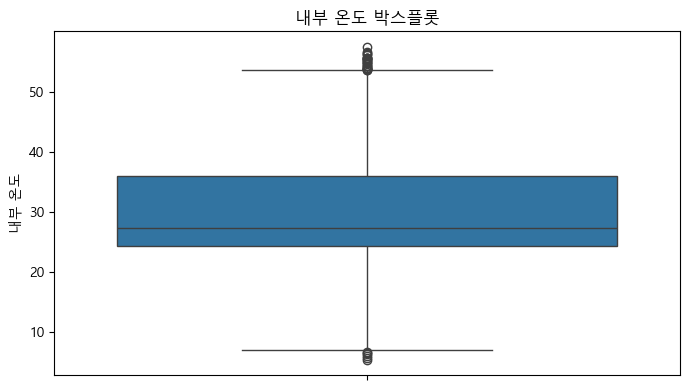

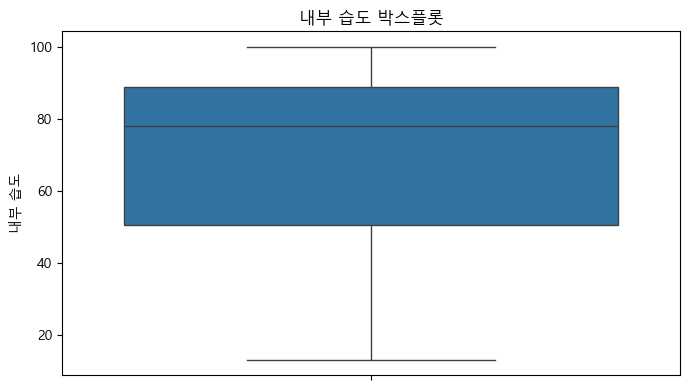

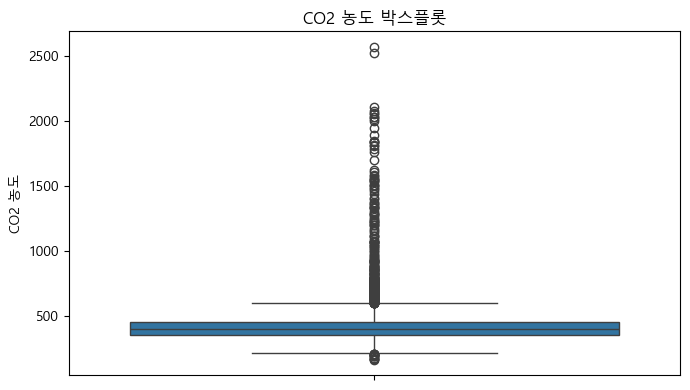

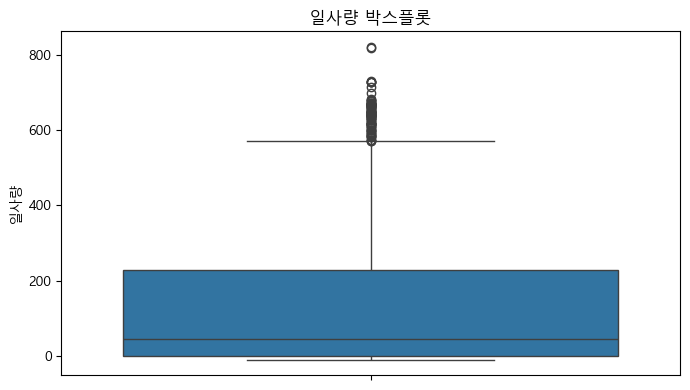

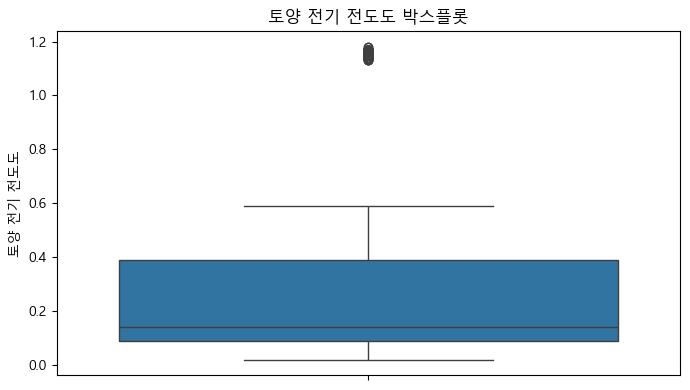

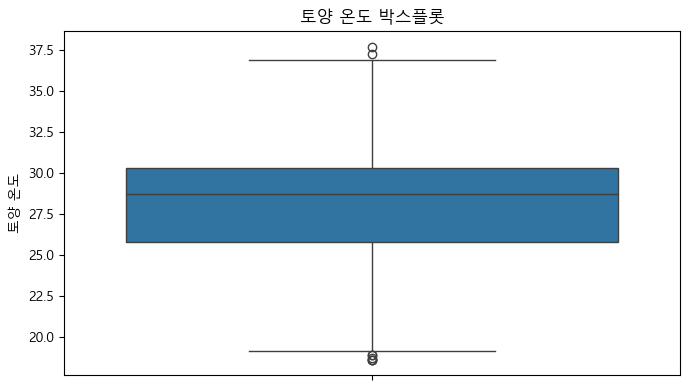

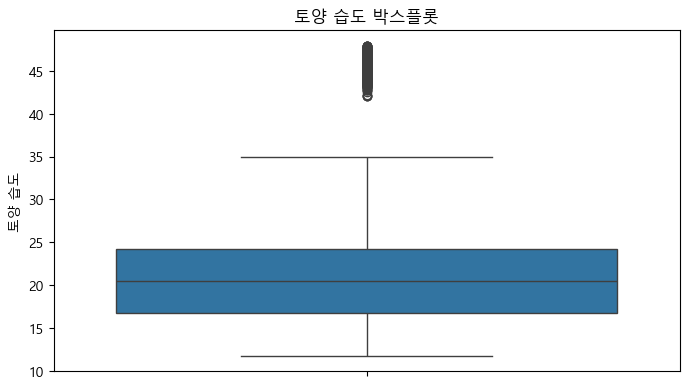

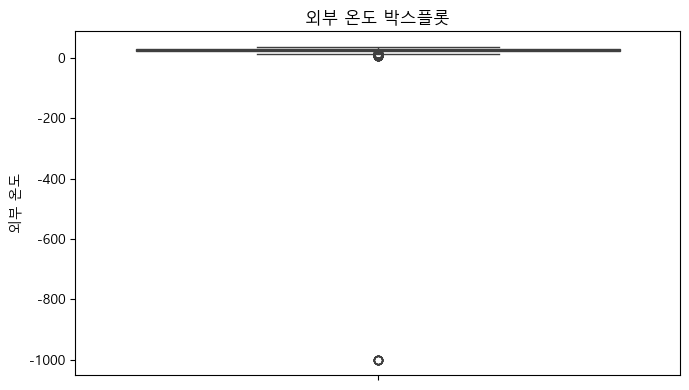

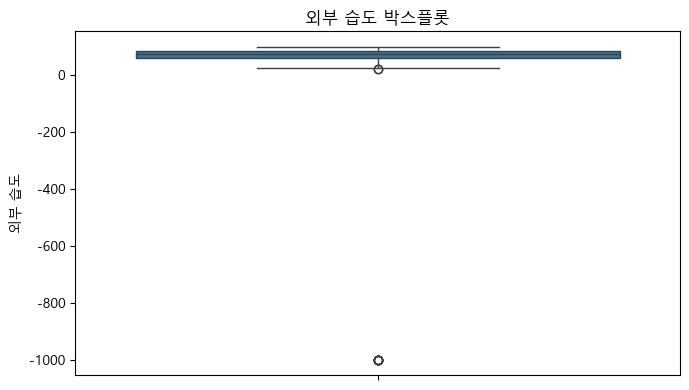

In [42]:
"""
    IQR 방식과 Z-score 방식 있음
    IQR 방식으로 제거

    이상치 해석
    - 내부 온도: 내부 온도 10도 이하?, 50도 이상? 오류일 가능성 존재
    - 내부 습도: 안정적
    - CO2 농도: 2500정도로 튀는 데이터 존재
    - 일사량: 600 이상인 데이터 존재
    - 토양 전기 전도도: 1.0 이상을 값 차이가 많이 큼
    - 토양 온도: 토양 온도 20도 이하?, 37도 이상? 제거 고려해도 될듯
    - 토양 습도: 40 이상인 이상치 존재함
    - 외부 온도/습도: 너무 극단적인 값 존재, 제거해도 될듯

    처리 전략
    - 외부 온도/습도 이상치 데이터는 제거(너무 극단적임)
    - 나머지 컬럼들의 이상치는 극단적이지 않아서 제거하지 않는 방향으로 이상치 처리 진행

"""
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 수치형 컬럼 선택
num_cols_lst = df_unique.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 박스플롯으로 시각화
for col in num_cols_lst:
    plt.figure(figsize=(7, 4))
    sns.boxplot(y=df_unique[col])
    plt.title(f'{col} 박스플롯')
    plt.tight_layout()
    plt.show()

In [43]:
# 고유값 데이터프레임을 다시 df에 저장
df = df_unique 

# 외부 온도 & 습도 이상치만 제거함
df = df[(df['외부 온도'] > -50) & (df['외부 온도'] < 60)]
df = df[(df['외부 습도'] >= 0) & (df['외부 습도'] <= 100)]

In [44]:
# 수치형 컬럼만 선택
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

# 이상치가 있는 행 저장
outlier_index = set()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 이상치 인덱스 추출
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_index.update(outliers)

print(f'이상치 포함 행 수: {len(outlier_index)}')

이상치 포함 행 수: 848


<Figure size 1500x600 with 0 Axes>

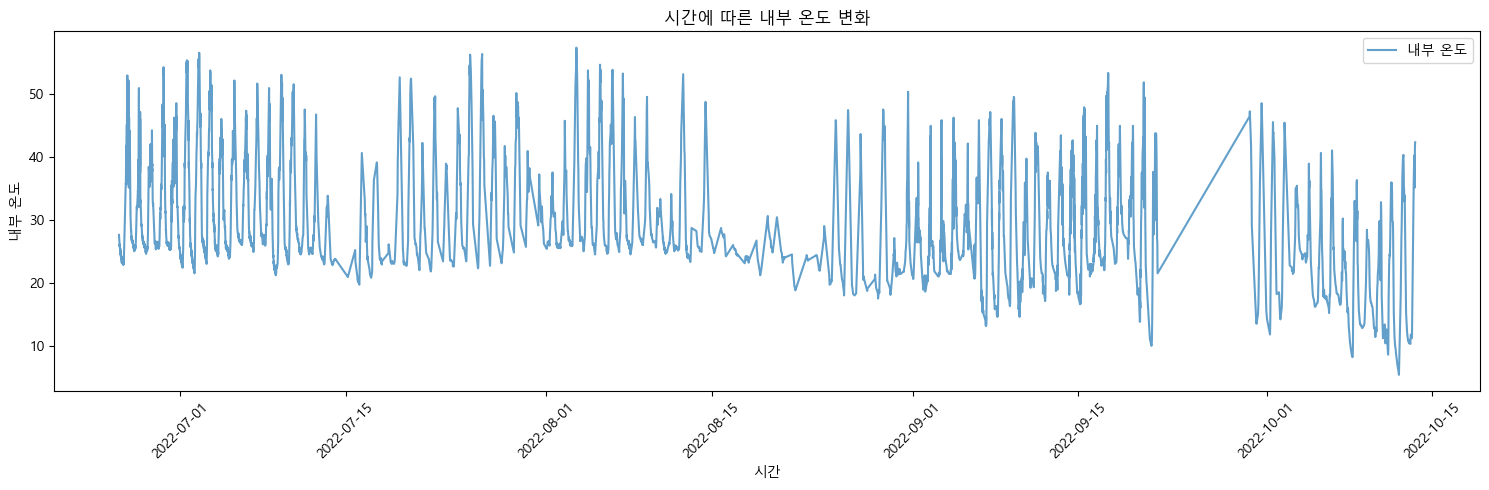

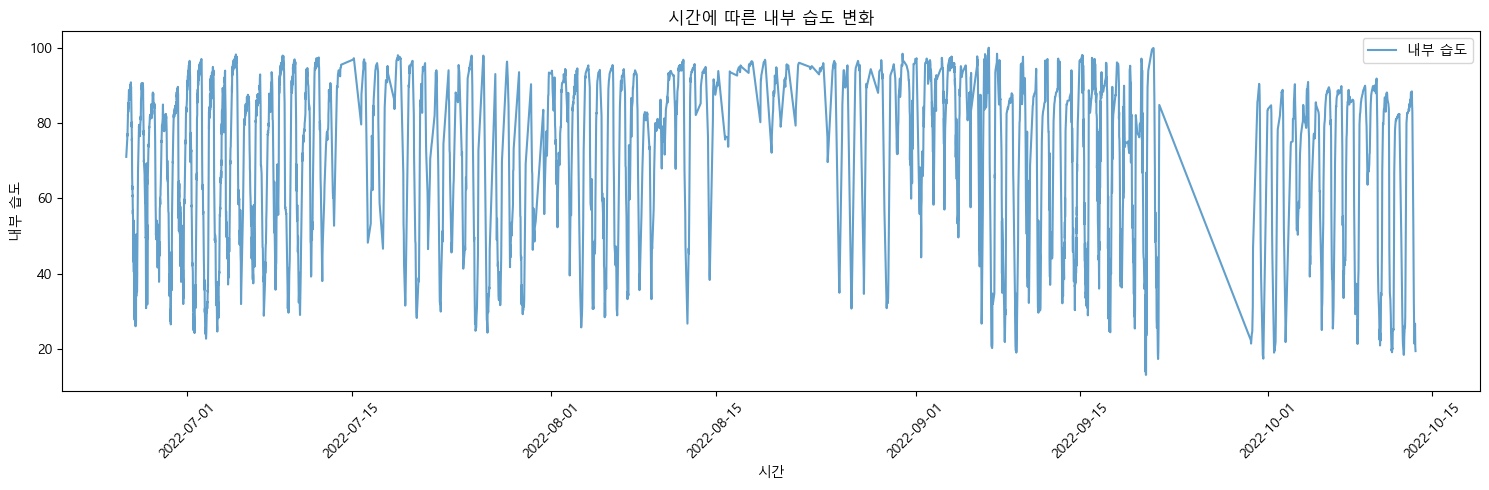

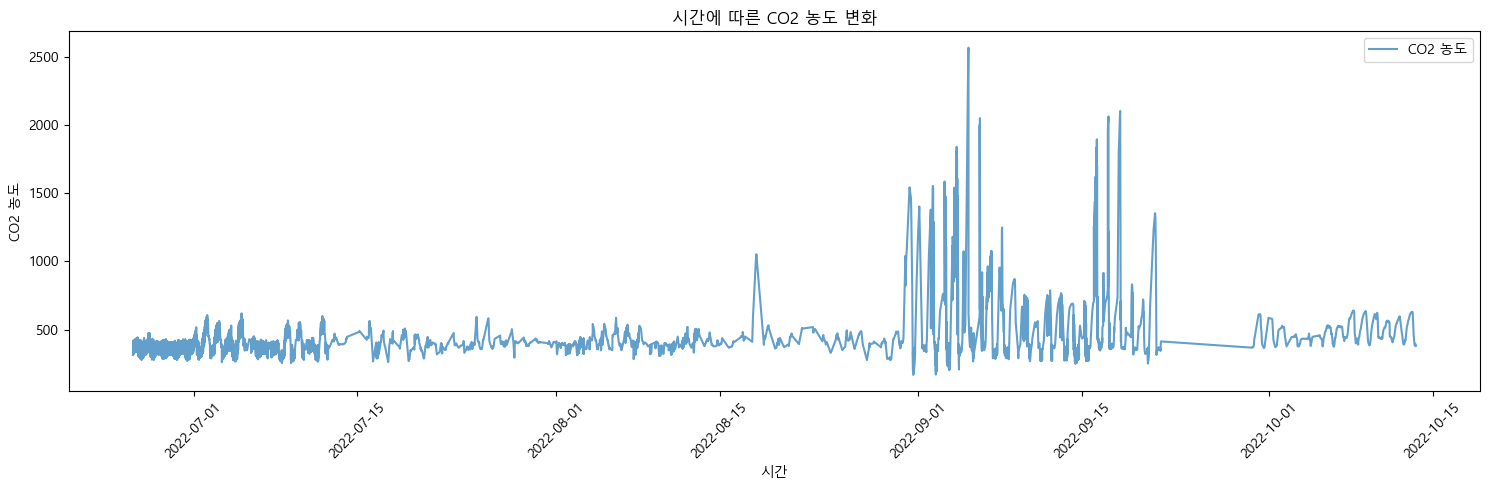

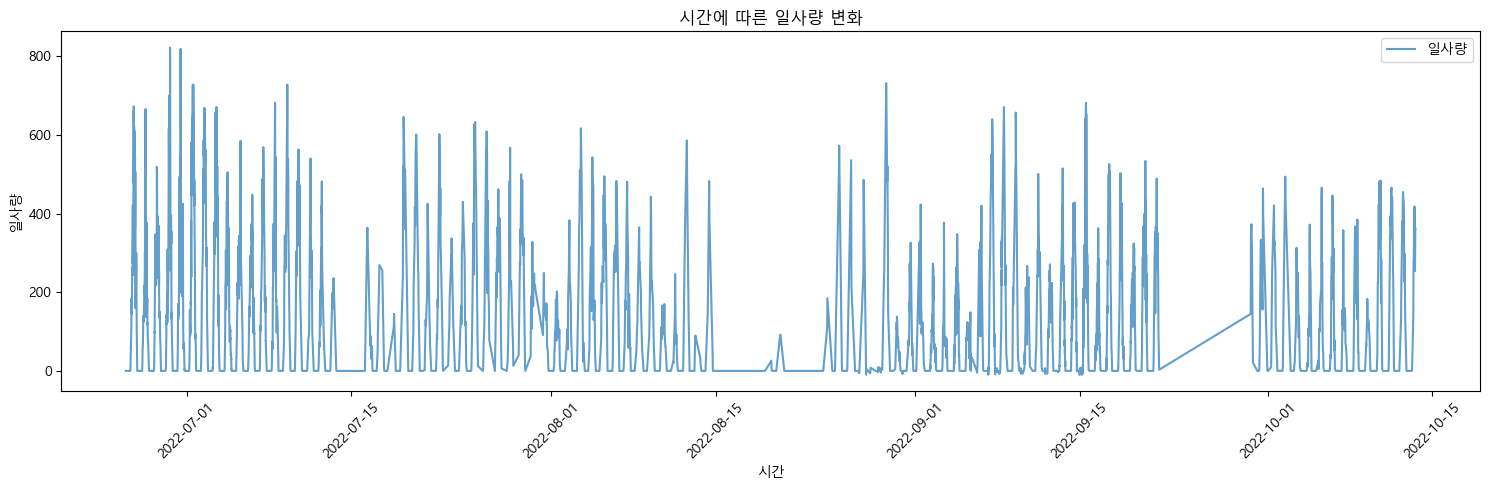

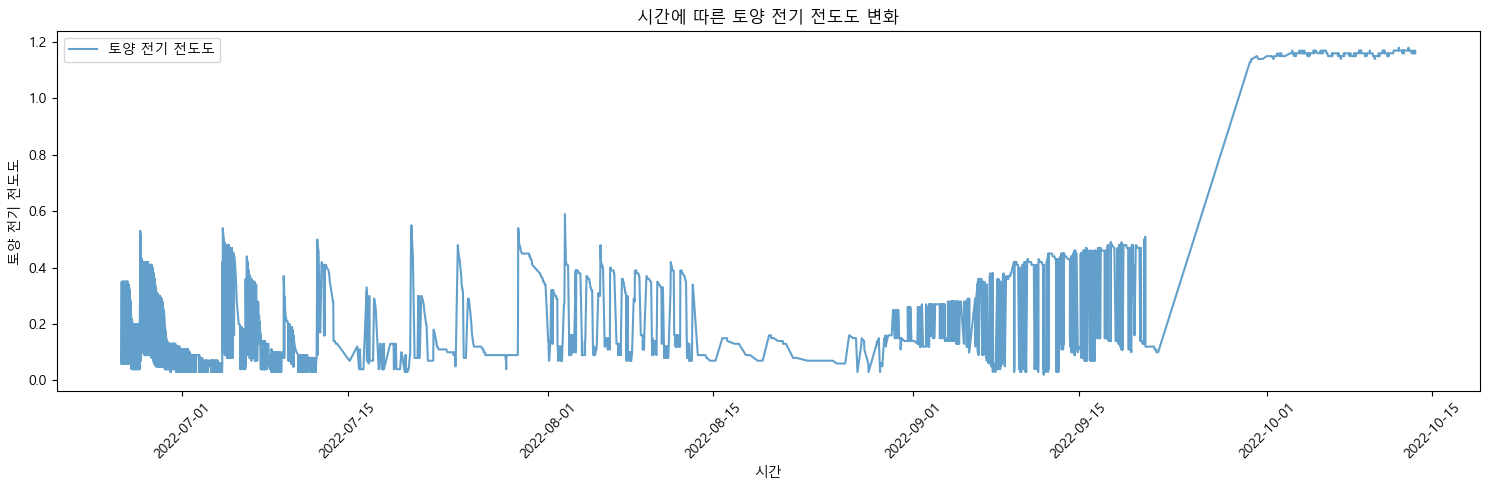

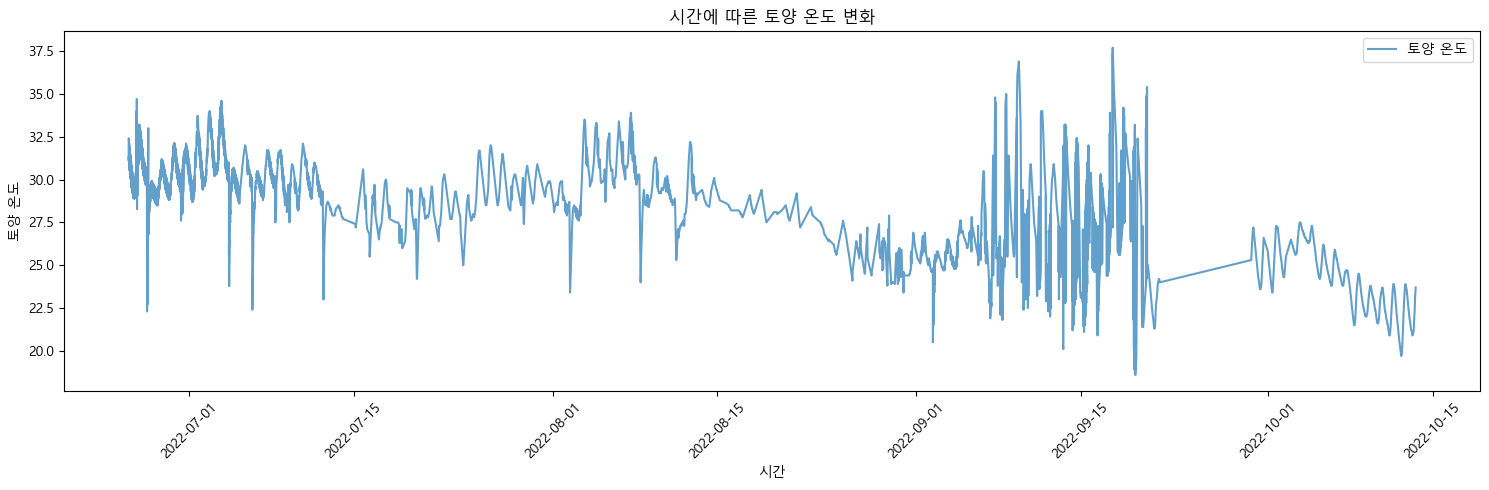

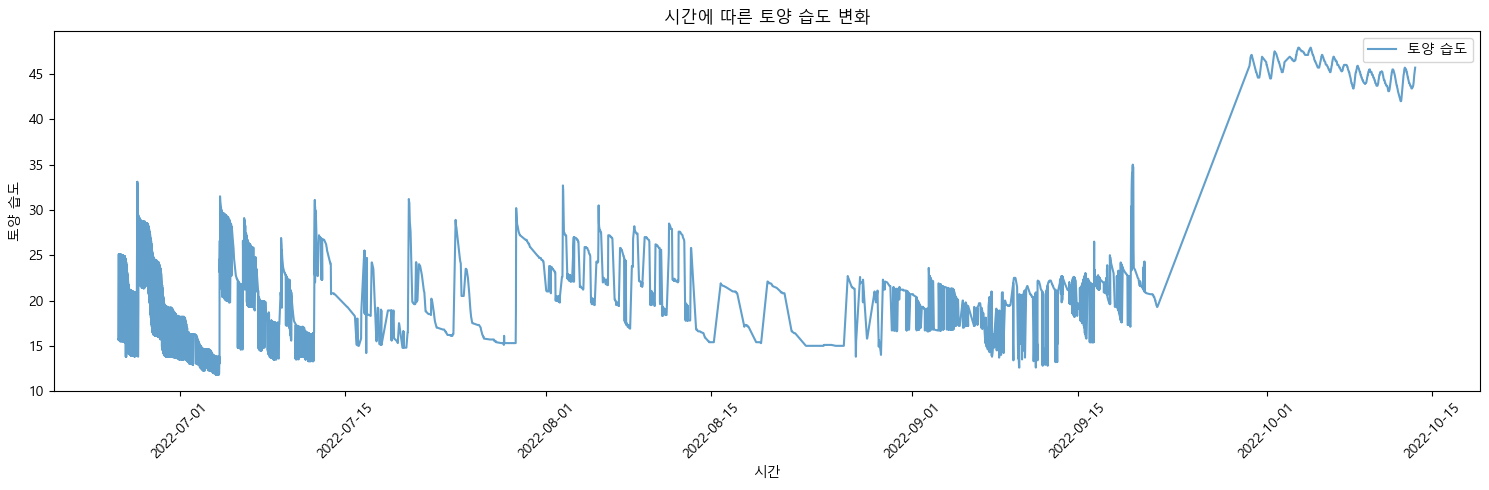

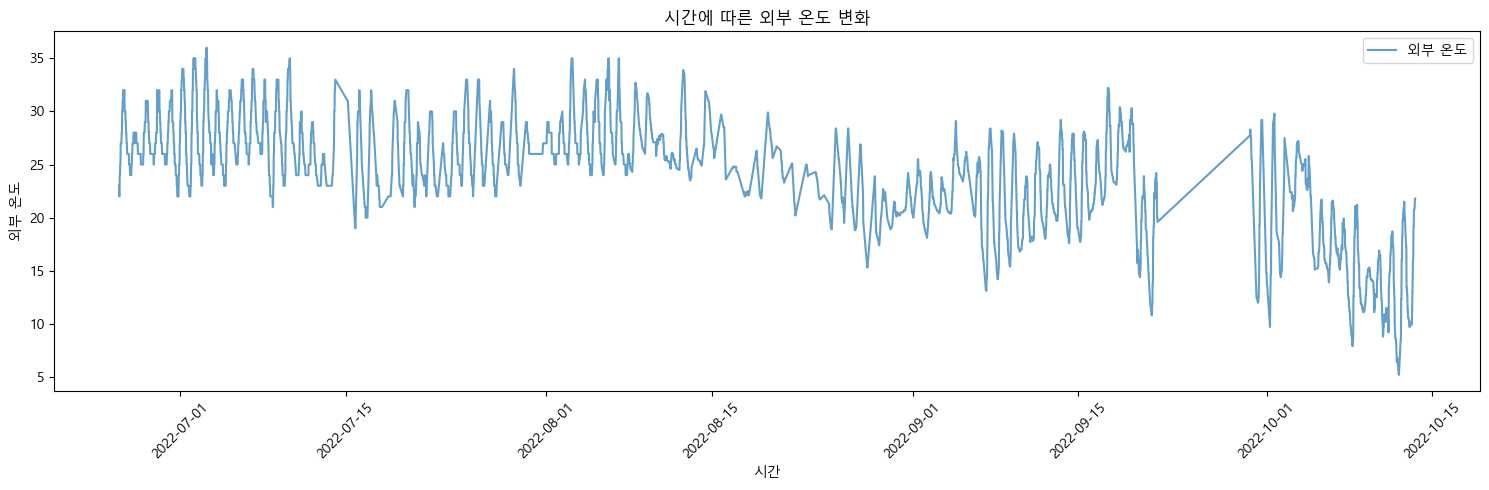

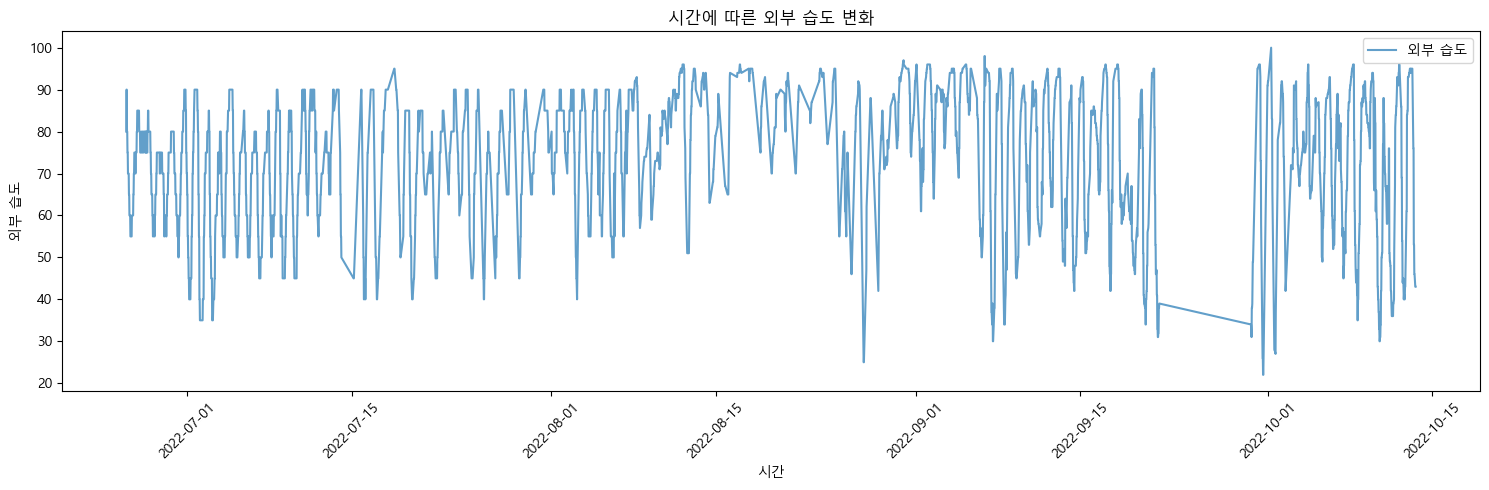

In [45]:
"""
    좀 더 확실하게 확인해보기 위해 데이터 수신시간 컬럼 기준으로 데이터 시각화

    확인 결과 이상치가 의심되긴 해도, 병해의 원인일 수도 있기 때문에 일단 유지
"""
num_col_lst = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
plt.figure(figsize=(15, 6))
for col in num_col_lst:
    plt.figure(figsize=(15, 5))
    plt.plot(df['데이터 수신시간'], df[col], label=col, alpha=0.7)
    plt.title(f'시간에 따른 {col} 변화')
    plt.xlabel('시간')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [46]:
"""
    이상치가 의심되는 row를 표시해 주는 컬럼 생성해줌

    향후 학습을 진행할때 이 컬럼을 통해 이상치들만 제거하여 학습 진행할 수 있게 함
"""
df['이상치_여부'] = 0
df.loc[list(outlier_index), '이상치_여부'] = 1

# boolean으로 데이터 타입 변경
df['이상치_여부'] = df['이상치_여부'].astype(bool)

df[df['이상치_여부'] == 1].head()

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간,이상치_여부
4673,정상,정식,48.9,30.4,312,673,0.11,33.8,20.8,맑음,26.0,75.0,2022-06-26 12:00:00,True
5000,정상,정식,48.4,31.6,304,660,0.15,34.0,20.1,맑음,26.0,75.0,2022-06-26 12:00:00,True
4405,정상,정식,50.2,32.3,313,666,0.15,33.1,20.1,맑음,26.0,75.0,2022-06-26 12:00:00,True
119,노균병,정식,51.2,31.4,309,668,0.13,34.0,21.1,맑음,26.0,75.0,2022-06-26 12:00:00,True
4675,정상,정식,48.7,31.5,312,662,0.14,32.5,20.1,맑음,26.0,75.0,2022-06-26 12:00:00,True


#### - 데이터 타입 변환

In [47]:
"""
    모든 object 컬럼들이 categorical 변수이므로 변환 진행

    날짜는 이미 datetime 타입으로 변환되어 있음
"""
# object 컬럼 추출
object_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in object_cols:
    df[col] = df[col].astype('category')
print(df.dtypes)


병해 유형              category
생육 단계              category
내부 온도               float64
내부 습도               float64
CO2 농도                int64
일사량                   int64
토양 전기 전도도           float64
토양 온도               float64
토양 습도               float64
강수 유무              category
외부 온도               float64
외부 습도               float64
데이터 수신시간     datetime64[ns]
이상치_여부                 bool
dtype: object


#### - 스케일링

In [48]:
"""
    스케일링 방법 크게 3가지 존재함
    1. 표준화: 평균0, 표준편차1로 변환 -> 대부분의 ML에 사용 가능함, 데이터가 정규 분포일 때 효과적
    2. 정규화: 0~1 선형 스케일링 -> 값의 절대 범위가 중요할 때 사용, 이상치에 민감함
    3. 로그 스케일링: log(1+x) 변환 -> 데이터의 분포가 심하게 오른쪽으로 치우친 경우 사용

    비대칭 정도를 수치로 측정하기 위해 왜도를 확인

    CO2 농도, 일사량, 전기 전도도, 토양 습도: 4개의 col의 왜도가 (1 <), (<-1) 이므로 로그 스케일링 적용
    하지만 각 변수에 음수 값이 있을 경우 shft 처리 후 로그 스케일링 적용해야 됨됨
    
"""
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# print(df.dtypes)
print(df[numeric_cols].skew())

df_scaled = df.copy()

# df_scaled의 4개의 변수 중에서 음수 값이 있는지 확인 -> 일사량에 음수 값 존재
print(df_scaled[['일사량', 'CO2 농도', '토양 전기 전도도', '토양 습도']].min())

# 일사량 음수 확인 및 shift 방식 적용
if (df_scaled['일사량'] < 0).any():
    min_val = df_scaled['일사량'].min()
    df_scaled['일사량'] = np.log1p(df_scaled['일사량'] - min_val + 1)
else:
    df_scaled['일사량'] = np.log1p(df_scaled['일사량'])

# 음수 값 있는 지 다시 확인인
print(df_scaled[['일사량', 'CO2 농도', '토양 전기 전도도', '토양 습도']].min())

# 로그 스케일링 적용
df_scaled['CO2 농도'] = np.log1p(df_scaled['CO2 농도'])
df_scaled['일사량'] = np.log1p(df_scaled['일사량'])
df_scaled['토양 전기 전도도'] = np.log1p(df_scaled['토양 전기 전도도'])
df_scaled['토양 습도'] = np.log1p(df_scaled['토양 습도'])

내부 온도        0.519016
내부 습도       -0.576087
CO2 농도       4.567920
일사량          1.340083
토양 전기 전도도    1.769940
토양 온도       -0.418627
토양 습도        1.591502
외부 온도       -0.824851
외부 습도       -0.493058
dtype: float64
일사량          -10.00
CO2 농도       169.00
토양 전기 전도도      0.02
토양 습도         11.80
dtype: float64
일사량            0.693147
CO2 농도       169.000000
토양 전기 전도도      0.020000
토양 습도         11.800000
dtype: float64


In [49]:
# df_scaled 중간확인
df_scaled.head()

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간,이상치_여부
4388,정상,정식,27.7,71.0,5.752573,1.248441,0.058269,31.3,2.815409,맑음,23.0,80.0,2022-06-25 19:30:00,False
4389,정상,정식,27.0,72.1,5.771441,1.248441,0.058269,31.1,2.815409,맑음,22.0,90.0,2022-06-25 20:00:00,False
3040,정상,정식,26.7,72.6,6.025866,1.248441,0.300105,32.4,3.261935,맑음,22.0,90.0,2022-06-25 20:00:00,False
2874,정상,정식,26.3,73.2,6.042633,1.248441,0.300105,32.2,3.261935,맑음,22.0,90.0,2022-06-25 20:30:00,False
4670,정상,정식,26.6,72.9,5.796058,1.248441,0.058269,31.0,2.815409,맑음,22.0,90.0,2022-06-25 20:30:00,False


In [50]:
"""
    로그 스케일링을 통해 분포가 왜곡된 변수들을 완하하였으므로 표준화 방식(z-score)으로 스케일링 진행

    스케일을 통일시켜 모델 학습 효율을 높임(특히 선형 모델, 거리 기반 모델에 중요하게 작용함)
"""

# 수치형 변수 추출
num_scaled_cols = df_scaled.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 표준화 방식으로 스케일러 적용
scaler = StandardScaler()
df_scaled[num_scaled_cols] = scaler.fit_transform(df_scaled[num_scaled_cols])


In [51]:
# df_scaled 중간확인
df_scaled.head()

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간,이상치_여부
4388,정상,정식,-0.253631,0.042840,-0.952320,-1.042691,-0.778501,1.044179,-0.893948,맑음,-0.348571,0.494289,2022-06-25 19:30:00,False
4389,정상,정식,-0.330032,0.092269,-0.889661,-1.042691,-0.778501,0.978995,-0.893948,맑음,-0.545871,1.118302,2022-06-25 20:00:00,False
3040,정상,정식,-0.362775,0.114737,-0.044760,-1.042691,0.305431,1.402685,0.468513,맑음,-0.545871,1.118302,2022-06-25 20:00:00,False
2874,정상,정식,-0.406433,0.141698,0.010920,-1.042691,0.305431,1.337502,0.468513,맑음,-0.545871,1.118302,2022-06-25 20:30:00,False
4670,정상,정식,-0.373690,0.128217,-0.807914,-1.042691,-0.778501,0.946404,-0.893948,맑음,-0.545871,1.118302,2022-06-25 20:30:00,False


#### - 인코딩

In [52]:
"""
    인코딩 방법에는 대표적으로로 두가지 방법이 있음
    1. One Hot Encoding: 각 범주마다 0/1 컬럼 생성 -> 대부분 모델에 적합하지만, 트리 기반 모델들에는 Label Encoding 보다 성능이 떨어질 수 있음
    2. Label Encoding: 범주를 숫자로 변환 -> 트리 기반 모델에 적합하지만, 범주 간 순서가 중요한 경우 문제 발생

    이번 분석에서는 One-Hot Encoding 방식으로 인코딩 진행
"""
categorical_cols = df_scaled.select_dtypes(include=['category']).columns.tolist()
df_scaled = pd.get_dummies(df_scaled, columns=categorical_cols, drop_first=True)

In [70]:
df_scaled.columns

Index(['내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도', '토양 온도', '토양 습도',
       '외부 온도', '외부 습도', '데이터 수신시간', '이상치_여부', '병해 유형_노균병유사', '병해 유형_정상',
       '병해 유형_흰가루병', '병해 유형_흰가루병유사', '생육 단계_정식', '생육 단계_착과', '강수 유무_비'],
      dtype='object')

In [54]:
# 데이터프레임의 요약 정보
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3703 entries, 4388 to 6453
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   병해 유형      3703 non-null   category      
 1   생육 단계      3703 non-null   category      
 2   내부 온도      3703 non-null   float64       
 3   내부 습도      3703 non-null   float64       
 4   CO2 농도     3703 non-null   int64         
 5   일사량        3703 non-null   int64         
 6   토양 전기 전도도  3703 non-null   float64       
 7   토양 온도      3703 non-null   float64       
 8   토양 습도      3703 non-null   float64       
 9   강수 유무      3703 non-null   category      
 10  외부 온도      3703 non-null   float64       
 11  외부 습도      3703 non-null   float64       
 12  데이터 수신시간   3703 non-null   datetime64[ns]
 13  이상치_여부     3703 non-null   bool          
dtypes: bool(1), category(3), datetime64[ns](1), float64(7), int64(2)
memory usage: 462.2 KB
None


In [55]:
# 3. 기초 통계량 확인
print(df.describe())

             내부 온도        내부 습도       CO2 농도          일사량    토양 전기 전도도  \
count  3703.000000  3703.000000  3703.000000  3703.000000  3703.000000   
mean     30.023819    70.046638   442.787470   128.944099     0.296514   
min       5.500000    13.100000   169.000000   -10.000000     0.020000   
25%      24.300000    50.550000   359.000000     0.000000     0.090000   
50%      27.400000    78.000000   405.000000    45.000000     0.140000   
75%      36.000000    88.900000   455.000000   228.000000     0.390000   
max      57.400000   100.000000  2567.000000   822.000000     1.180000   
std       9.163430    22.257106   196.962079   168.858819     0.340746   

             토양 온도        토양 습도        외부 온도        외부 습도  \
count  3703.000000  3703.000000  3703.000000  3703.000000   
mean     28.096165    22.753605    24.766703    72.078855   
min      18.600000    11.800000     5.200000    22.000000   
25%      25.800000    16.800000    22.100000    60.000000   
50%      28.700000    20.500

In [56]:
# 컬럼명 목록 확인
print(df.columns)

Index(['병해 유형', '생육 단계', '내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도',
       '토양 온도', '토양 습도', '강수 유무', '외부 온도', '외부 습도', '데이터 수신시간', '이상치_여부'],
      dtype='object')


In [57]:
# 결측치 확인
print(df.isnull().sum())

병해 유형        0
생육 단계        0
내부 온도        0
내부 습도        0
CO2 농도       0
일사량          0
토양 전기 전도도    0
토양 온도        0
토양 습도        0
강수 유무        0
외부 온도        0
외부 습도        0
데이터 수신시간     0
이상치_여부       0
dtype: int64


In [58]:
# 데이터 타입 확인
print(df.dtypes)

병해 유형              category
생육 단계              category
내부 온도               float64
내부 습도               float64
CO2 농도                int64
일사량                   int64
토양 전기 전도도           float64
토양 온도               float64
토양 습도               float64
강수 유무              category
외부 온도               float64
외부 습도               float64
데이터 수신시간     datetime64[ns]
이상치_여부                 bool
dtype: object


In [59]:
# 데이터프레임의 크기 (행, 열 수)
print(df.shape)

(3703, 14)


## 3. 데이터 탐색

### 범주형 특성 탐색

In [60]:
# 범주형 변수 추출
categorical_cols = df.select_dtypes(include=['object']).columns

# 각 범주형 변수에 대해 고유값, 빈도수 등 확인
for col in categorical_cols:
    print(f'- Column: {col}')
    print(df[col].value_counts())
    print('고유값 개수:', df[col].nunique())
    print('-' * 40)

### 수치형 특성 탐색

Index(['내부 온도', '내부 습도', 'CO2 농도', '일사량', '토양 전기 전도도', '토양 온도', '토양 습도',
       '외부 온도', '외부 습도'],
      dtype='object')
             내부 온도        내부 습도       CO2 농도          일사량    토양 전기 전도도  \
count  3703.000000  3703.000000  3703.000000  3703.000000  3703.000000   
mean     30.023819    70.046638   442.787470   128.944099     0.296514   
std       9.163430    22.257106   196.962079   168.858819     0.340746   
min       5.500000    13.100000   169.000000   -10.000000     0.020000   
25%      24.300000    50.550000   359.000000     0.000000     0.090000   
50%      27.400000    78.000000   405.000000    45.000000     0.140000   
75%      36.000000    88.900000   455.000000   228.000000     0.390000   
max      57.400000   100.000000  2567.000000   822.000000     1.180000   

             토양 온도        토양 습도        외부 온도        외부 습도  
count  3703.000000  3703.000000  3703.000000  3703.000000  
mean     28.096165    22.753605    24.766703    72.078855  
std       3.068697     9.163674 

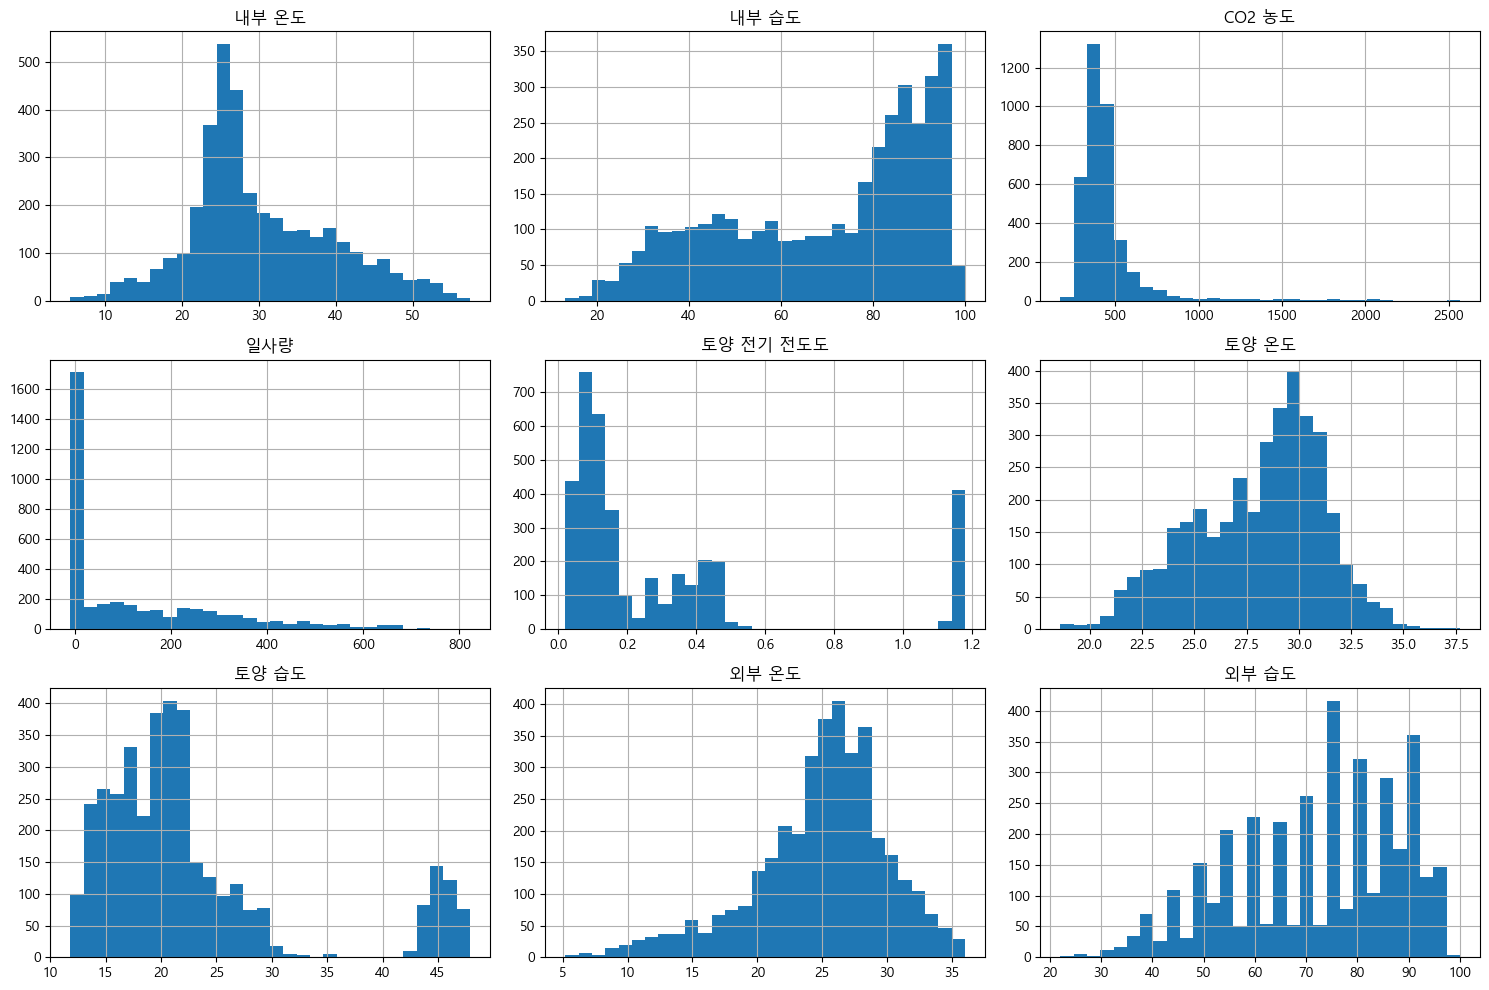

In [61]:
# 수치형 변수 추출
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_cols)

# 기초 통계량 확인
print(df[numerical_cols].describe())

# 한글 폰트 설정 (예: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

### 데이터 관계 시각화

#### - 산점도

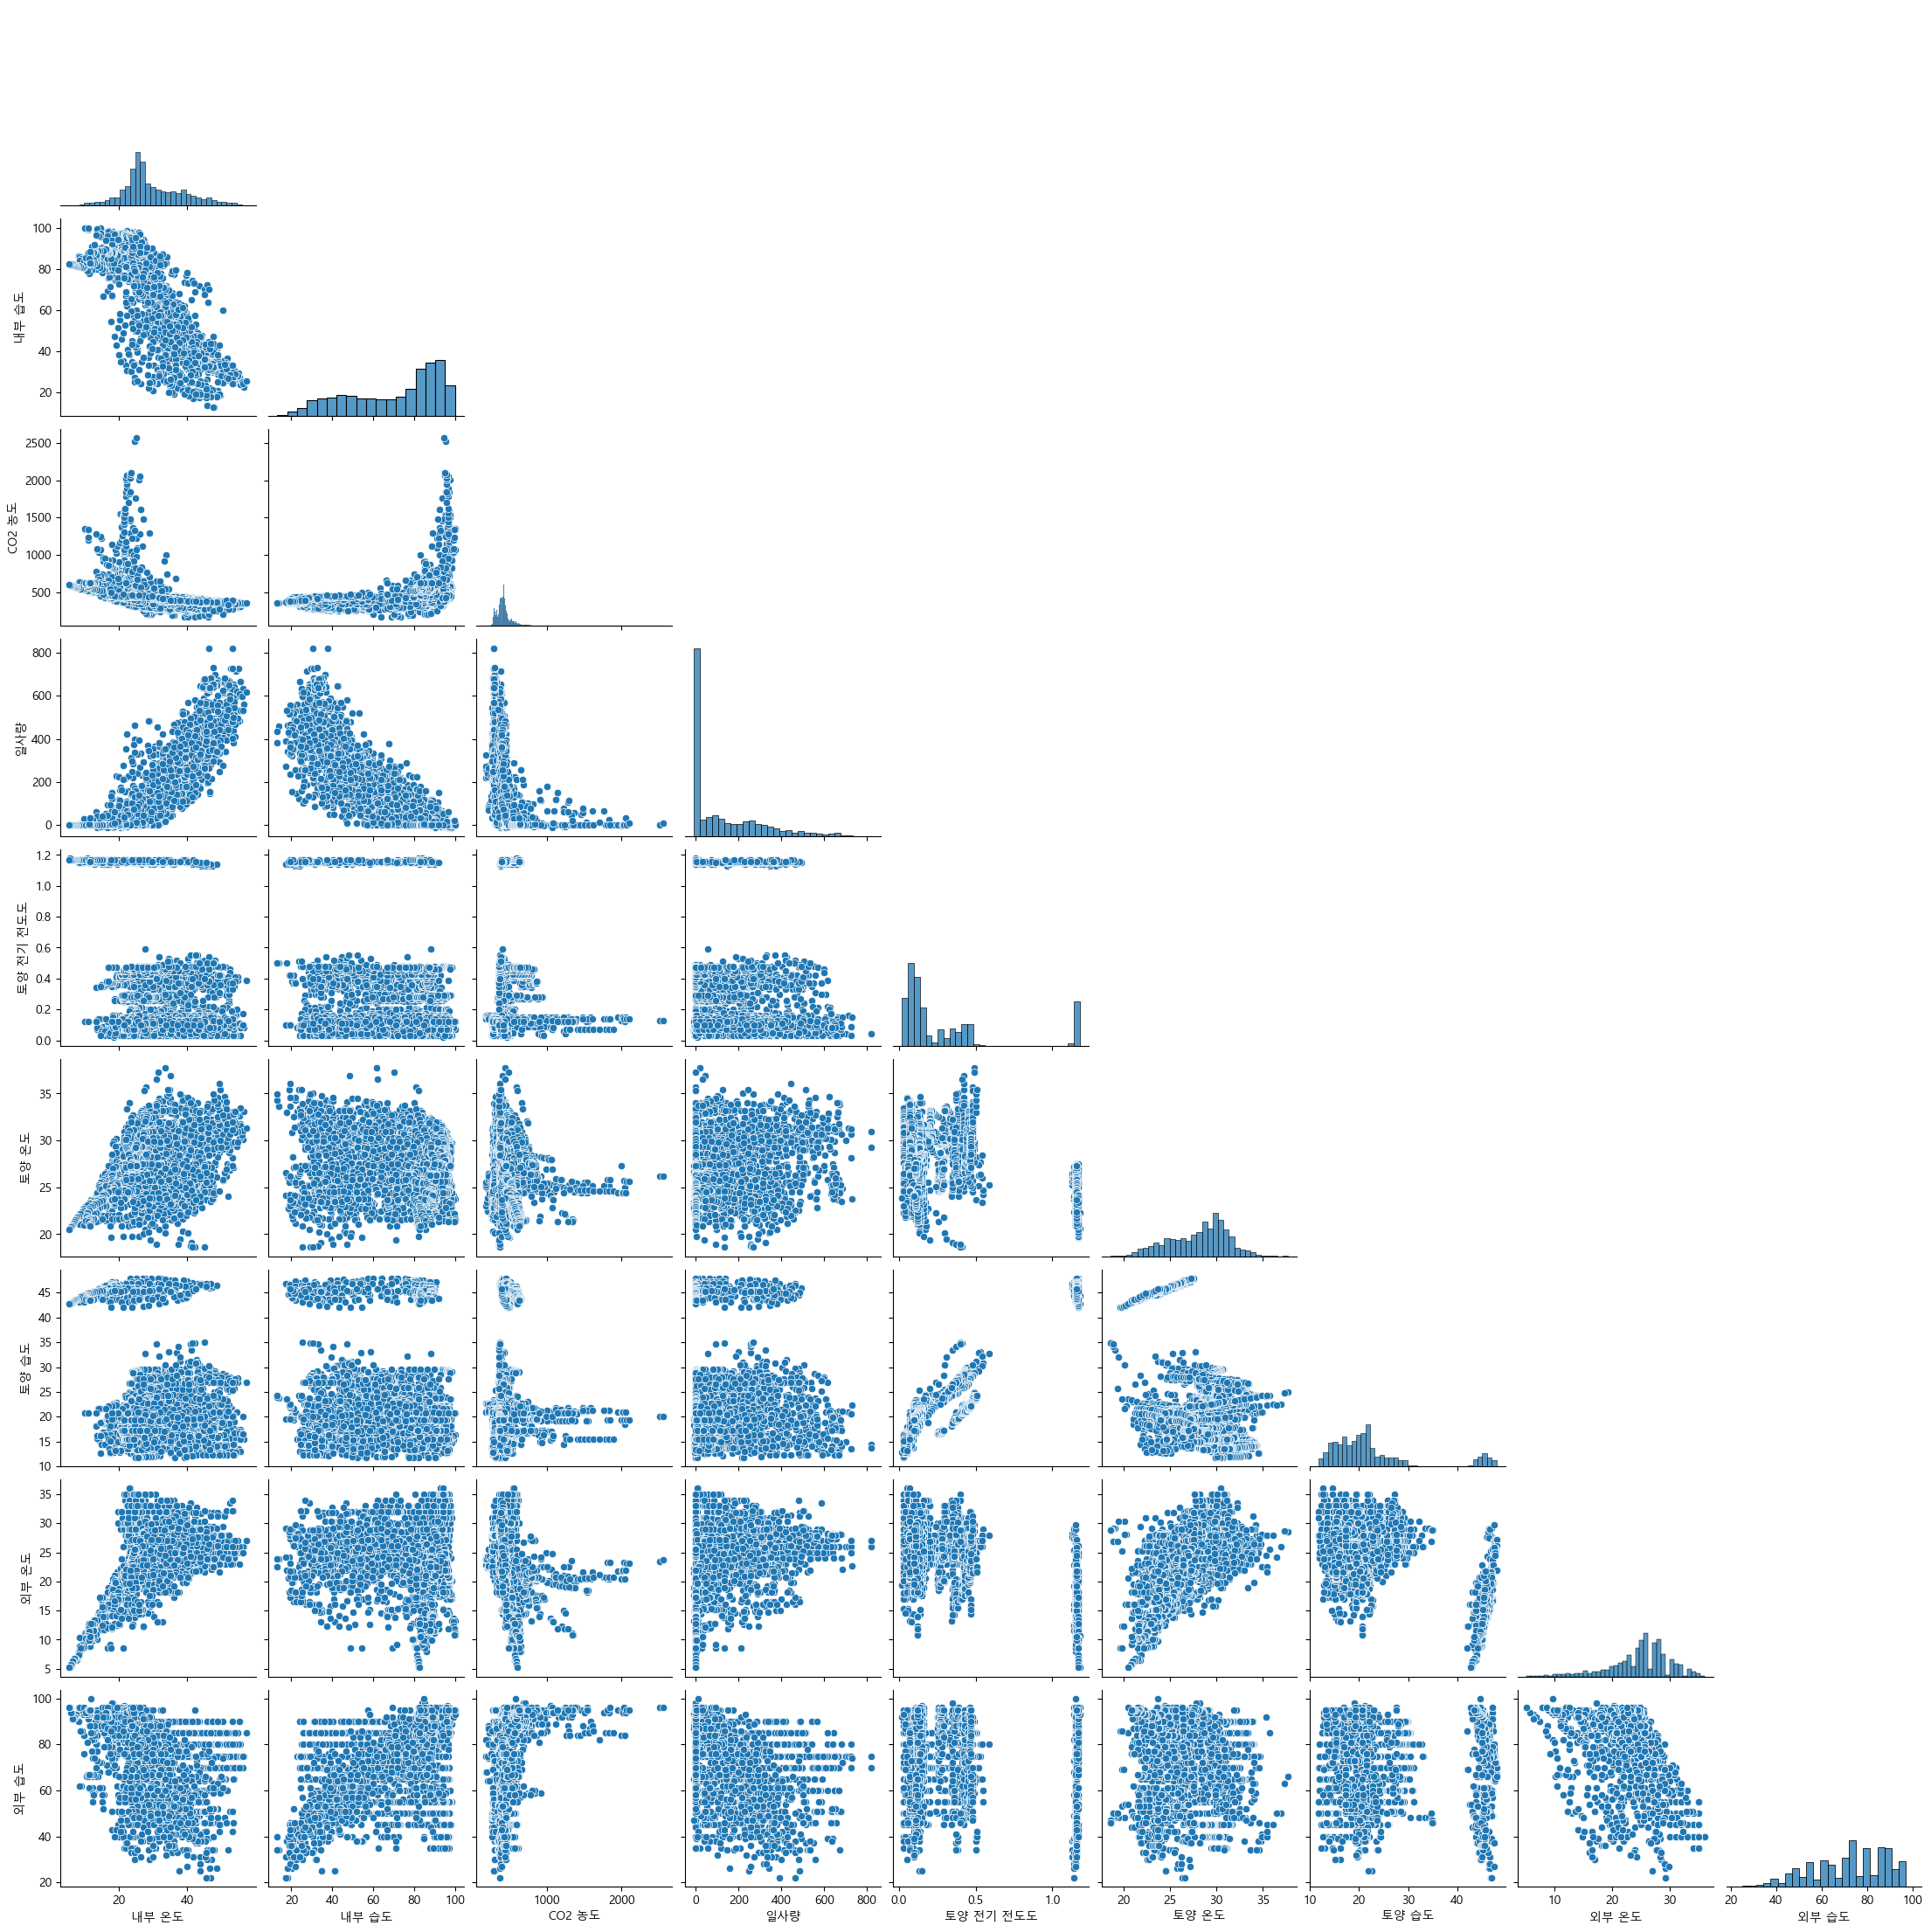

In [62]:
# 수치형 변수만 선택
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# 산점도
sns.pairplot(numerical_df, corner=True)
plt.show()

#### - 상관계수 히트맵

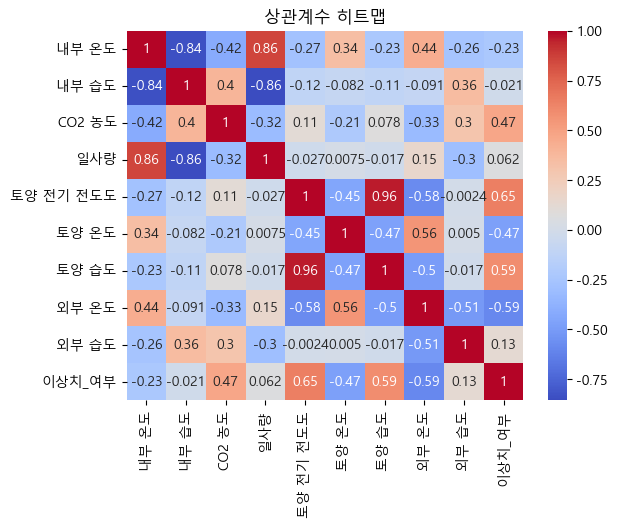

In [63]:
corr = df.corr(numeric_only=True)  # 수치형만 상관계수 계산
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('상관계수 히트맵')
plt.show()

#### - 박스 플롯

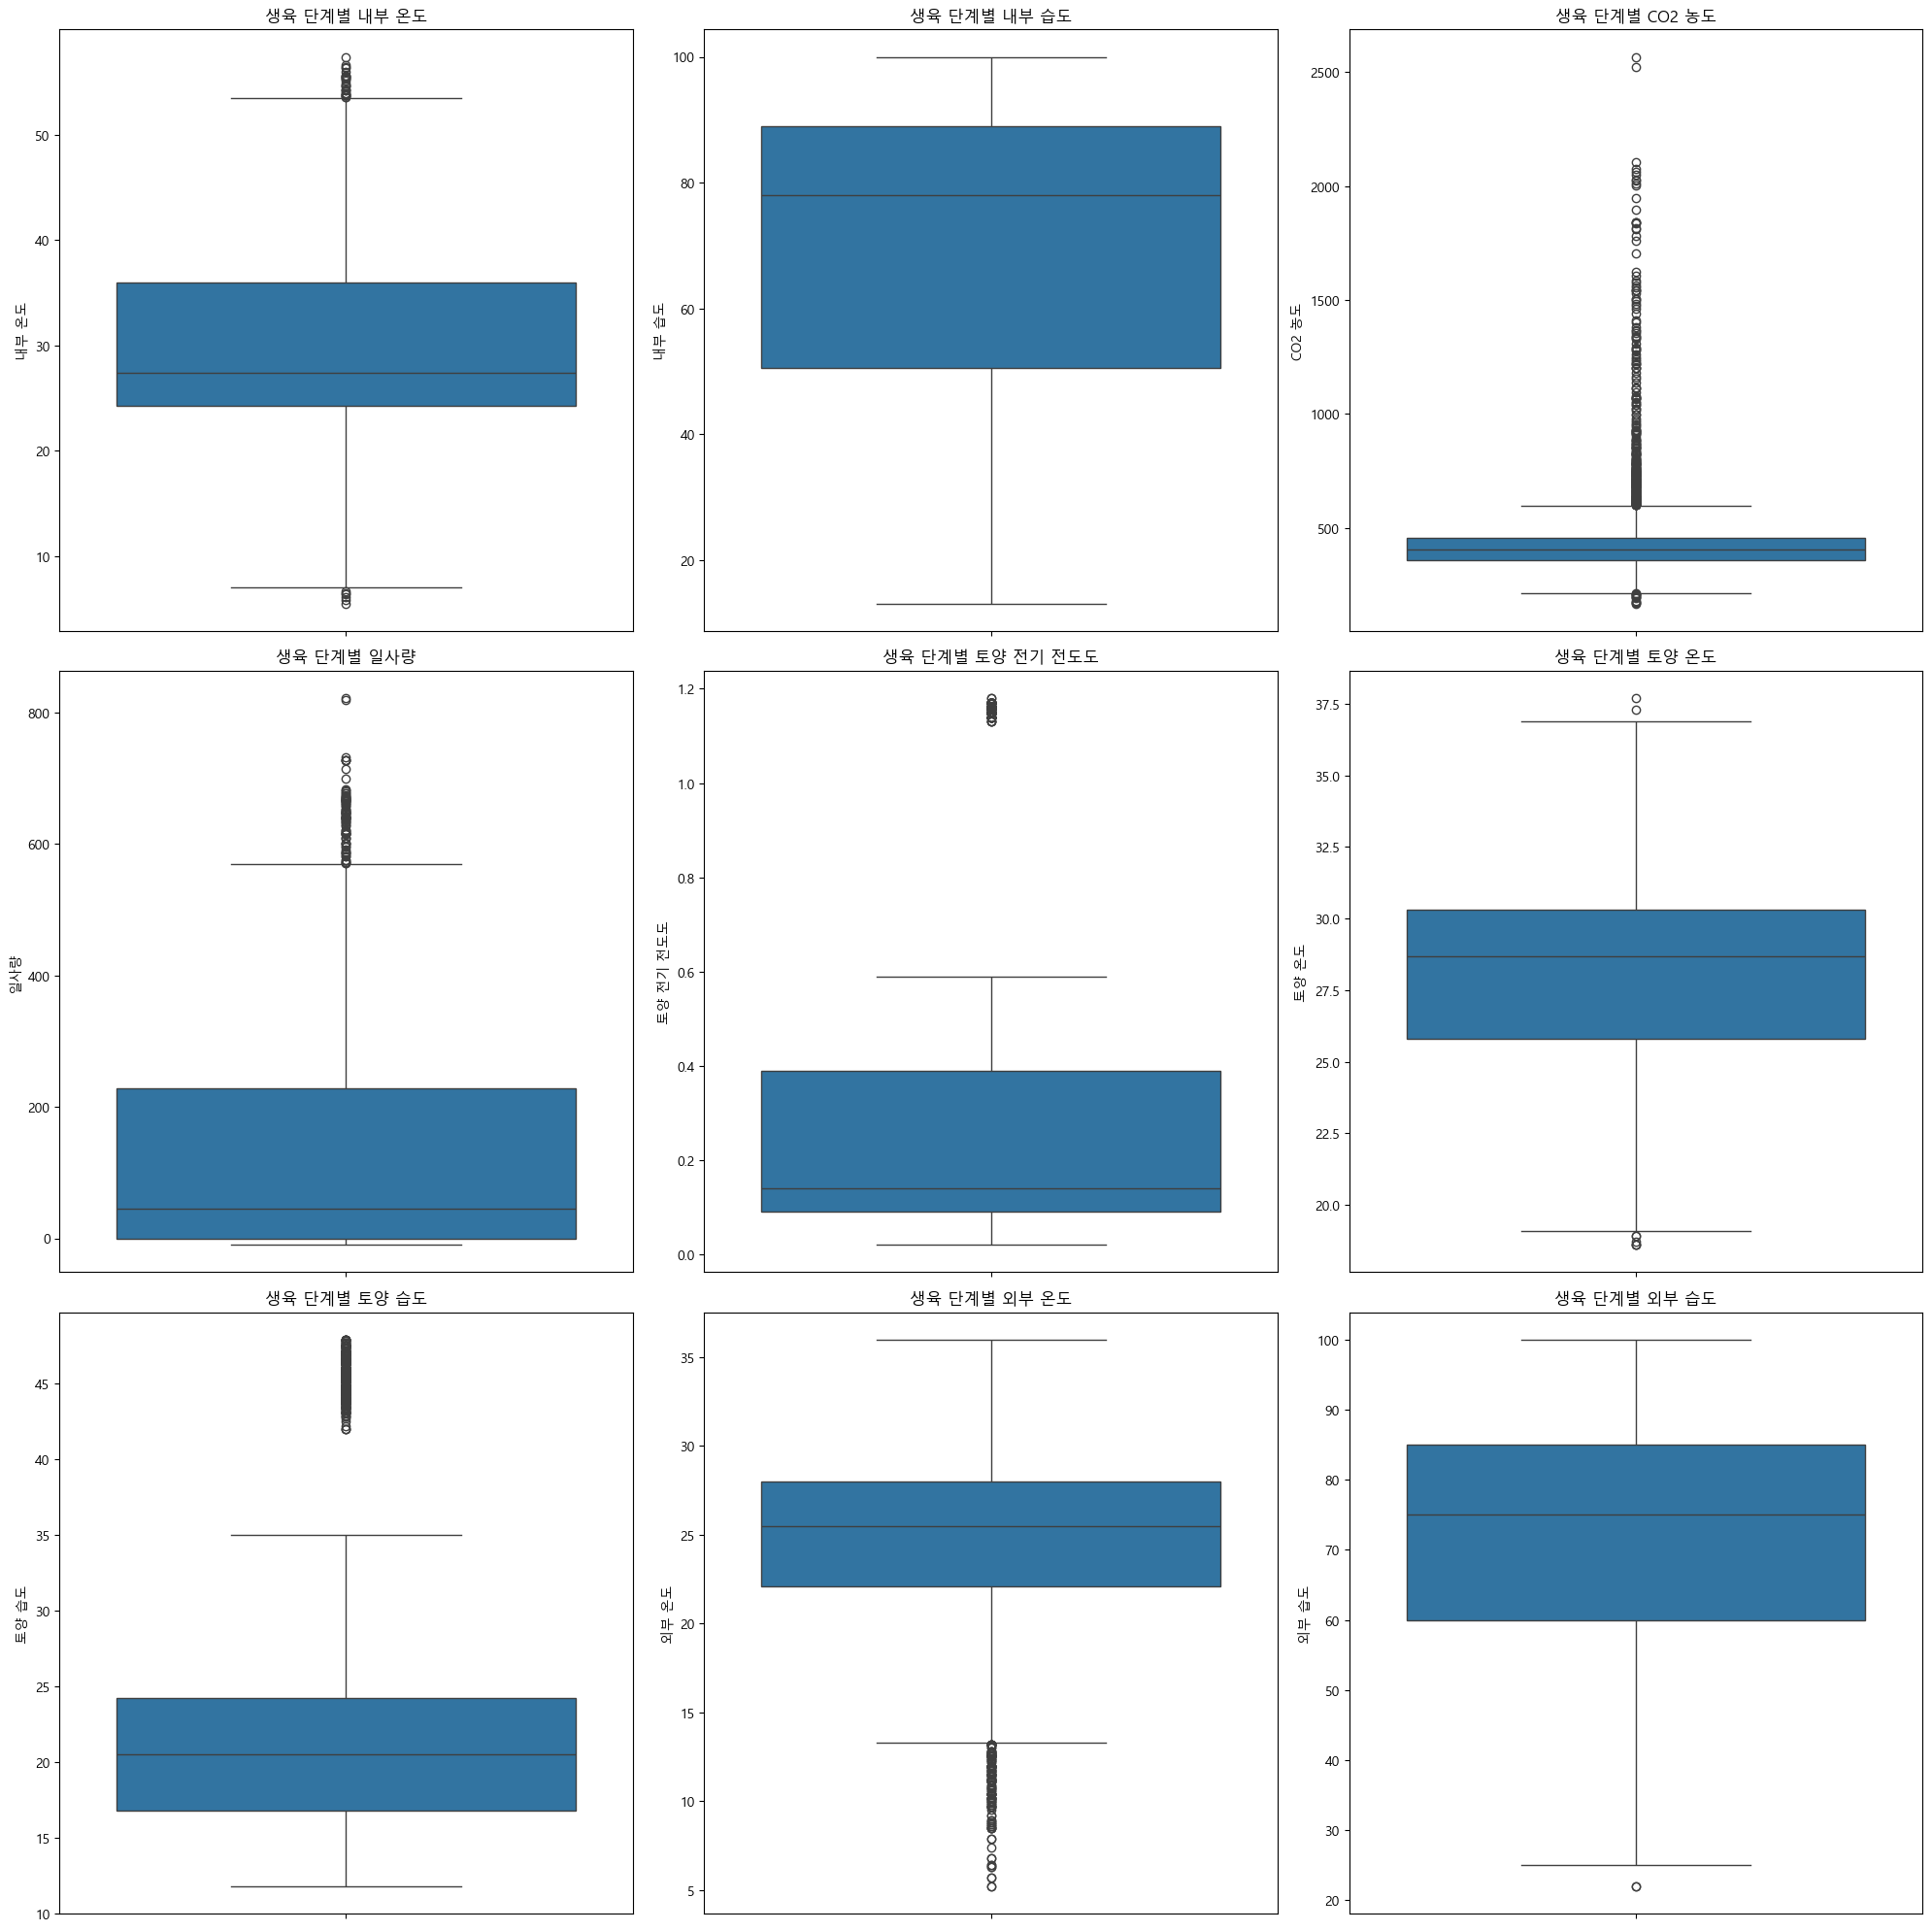

In [64]:
numerical_cols_lst = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

#  기준이 되는 범주형 변수 (예: 생육 단계 또는 강수 유무)
target_column = '생육 단계'  # 또는 '강수 유무'

# subplot 만들기 (3행 3열)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
axes = axes.flatten()

# 박스플롯 반복
for i, col in enumerate(numerical_cols_lst):
    sns.boxplot(y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{target_column}별 {col}')
    axes[i].tick_params(axis='x', rotation=45)  # x축 범주 회전

plt.tight_layout()
plt.show()

#### - 시계열 데이터

In [65]:
# '데이터 수신시간' 컬럼을 datetime 타입으로 변환
df['데이터 수신시간'] = pd.to_datetime(df['데이터 수신시간'])

# 시간 기준 정렬 (필수!)
df = df.sort_values('데이터 수신시간')
df.head()

,병해 유형,생육 단계,내부 온도,내부 습도,CO2 농도,일사량,토양 전기 전도도,토양 온도,토양 습도,강수 유무,외부 온도,외부 습도,데이터 수신시간,이상치_여부
4388,정상,정식,27.7,71.0,314,0,0.06,31.3,15.7,맑음,23.0,80.0,2022-06-25 19:30:00,False
4389,정상,정식,27.0,72.1,320,0,0.06,31.1,15.7,맑음,22.0,90.0,2022-06-25 20:00:00,False
3040,정상,정식,26.7,72.6,413,0,0.35,32.4,25.1,맑음,22.0,90.0,2022-06-25 20:00:00,False
2874,정상,정식,26.3,73.2,420,0,0.35,32.2,25.1,맑음,22.0,90.0,2022-06-25 20:30:00,False
4670,정상,정식,26.6,72.9,328,0,0.06,31.0,15.7,맑음,22.0,90.0,2022-06-25 20:30:00,False


<Figure size 1500x600 with 0 Axes>

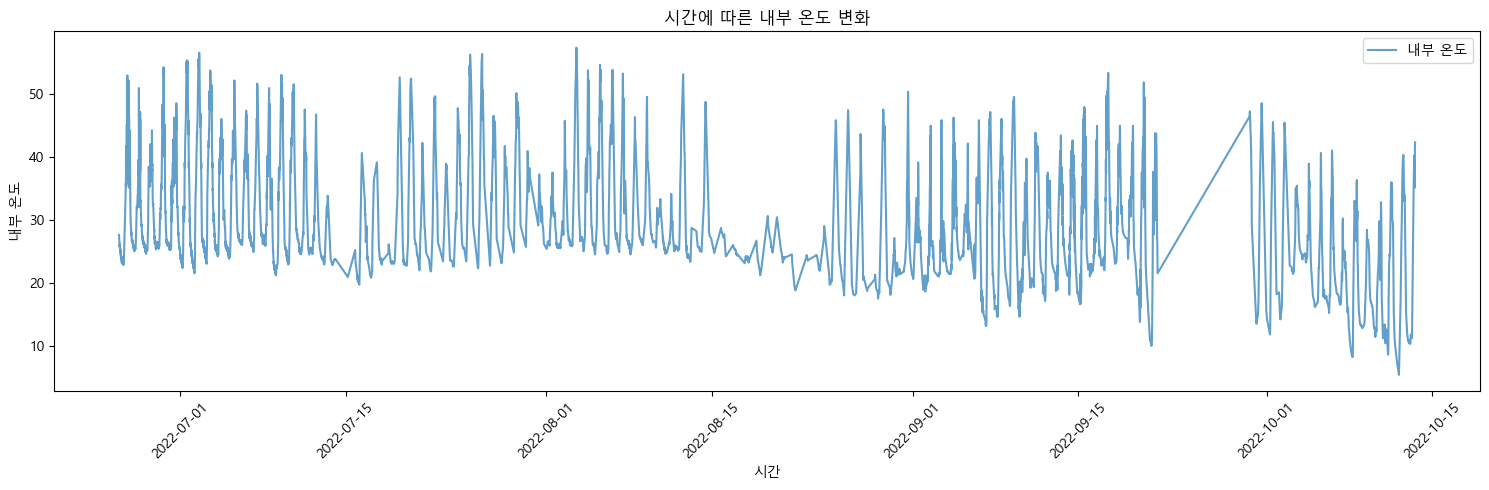

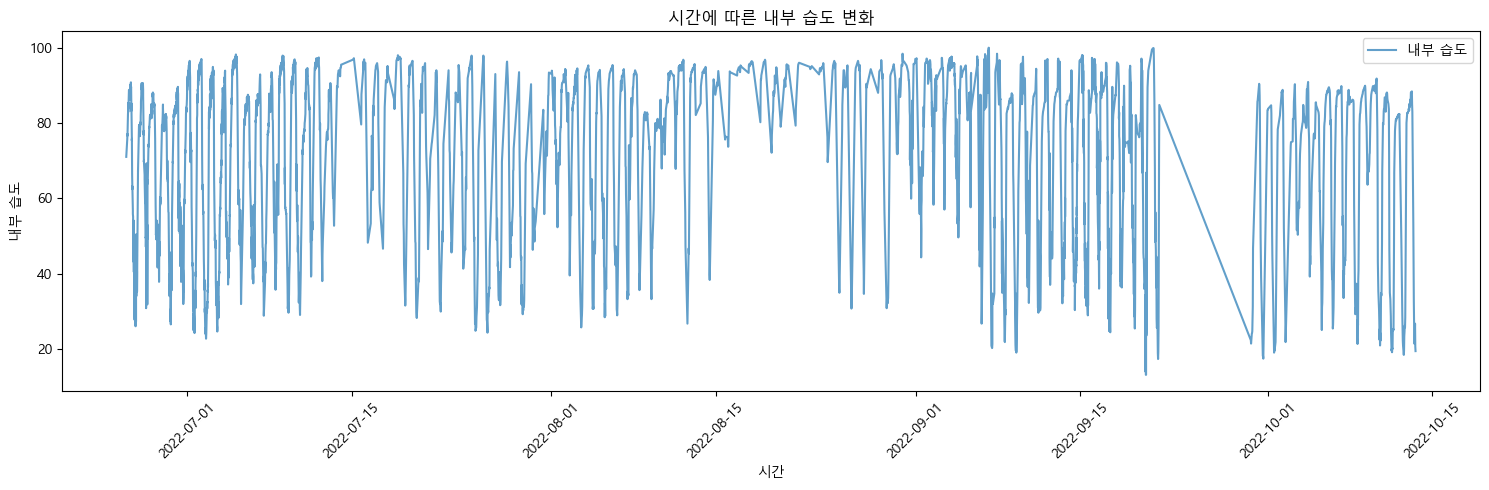

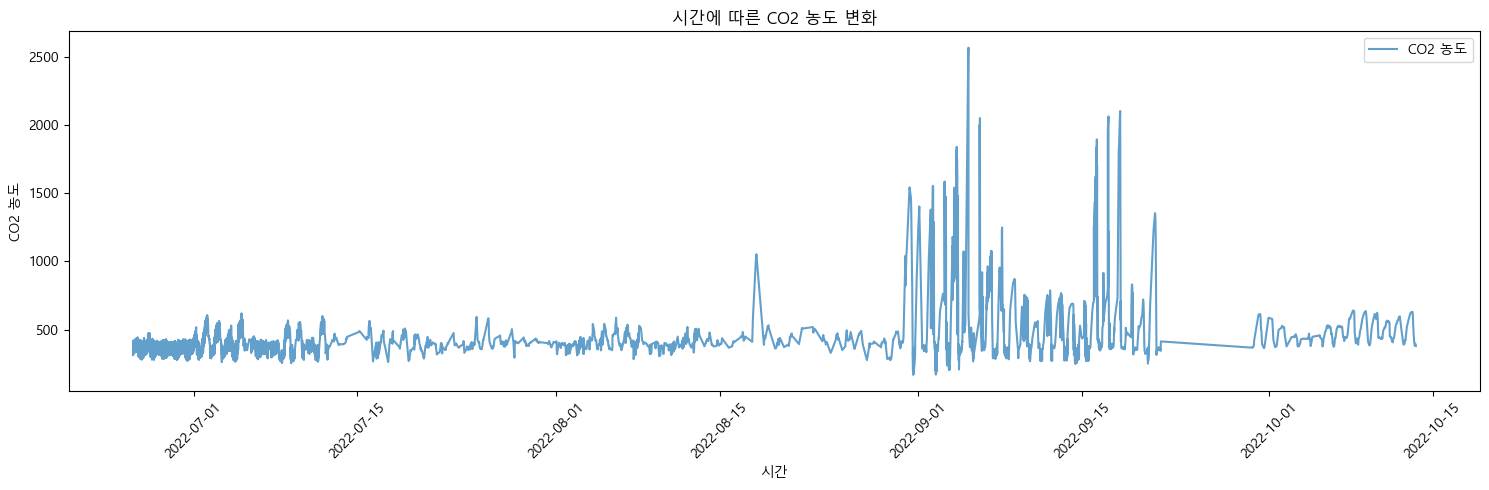

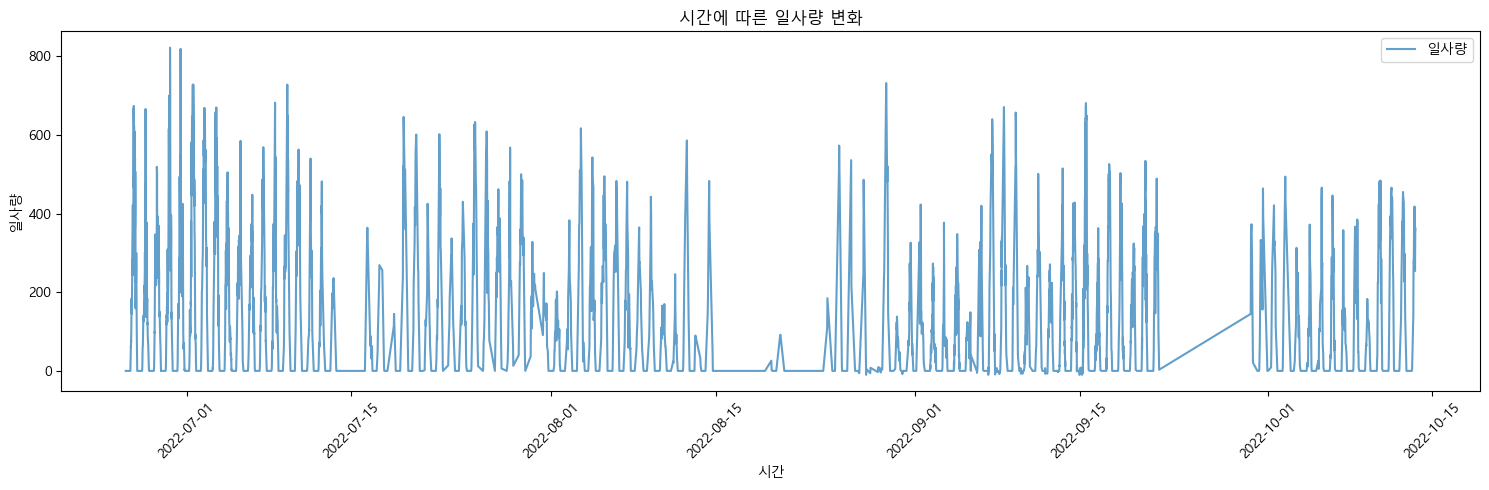

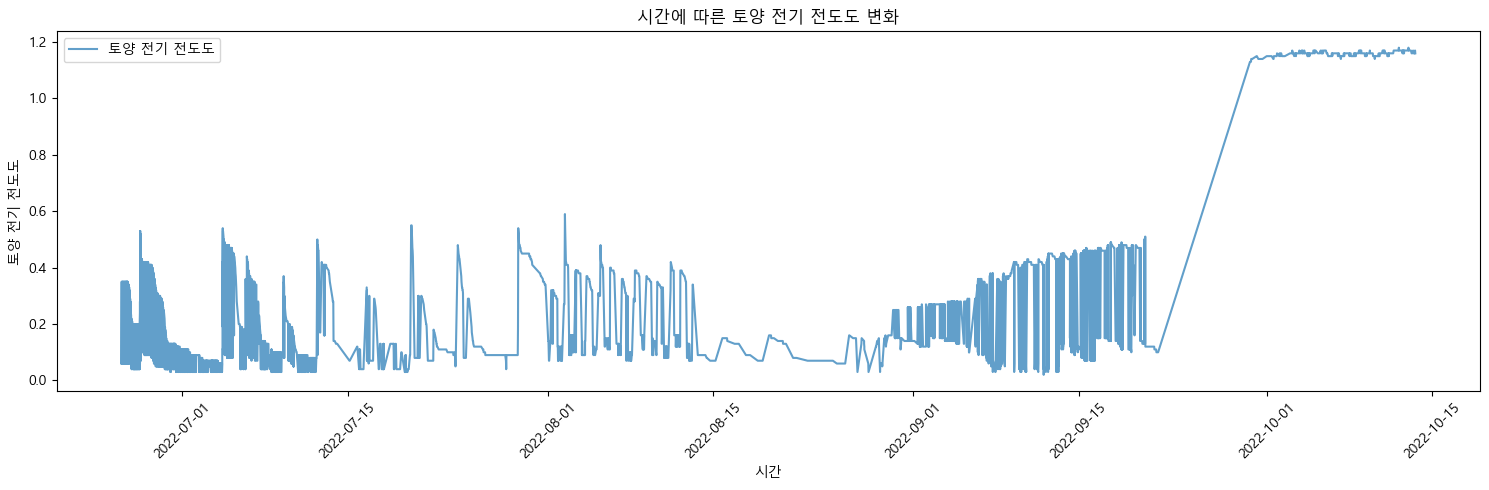

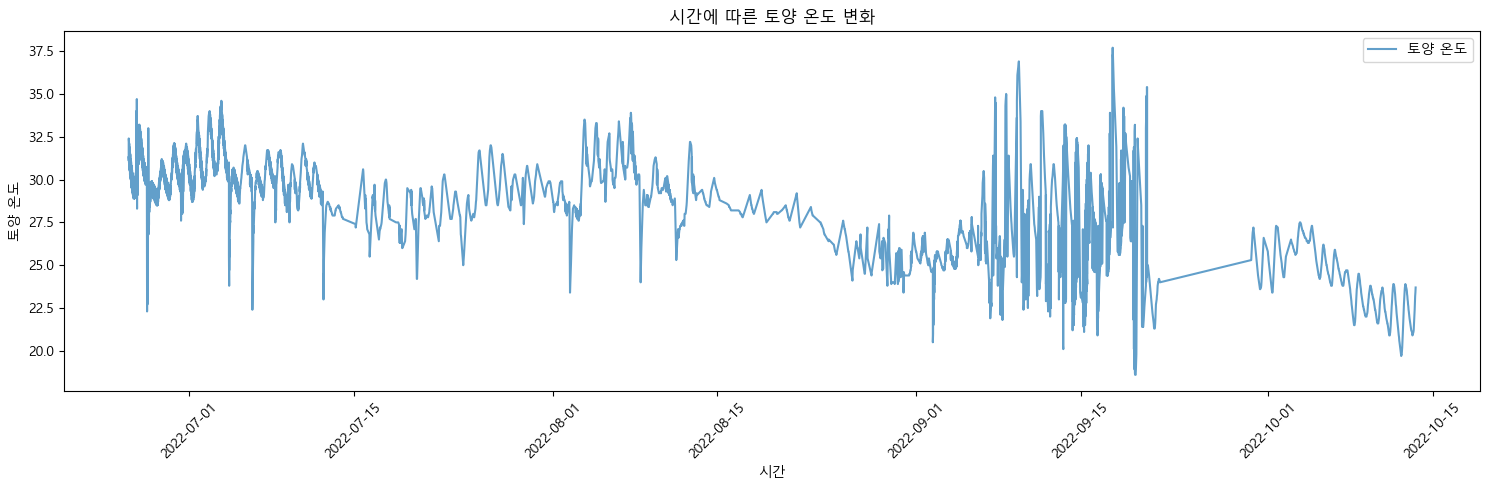

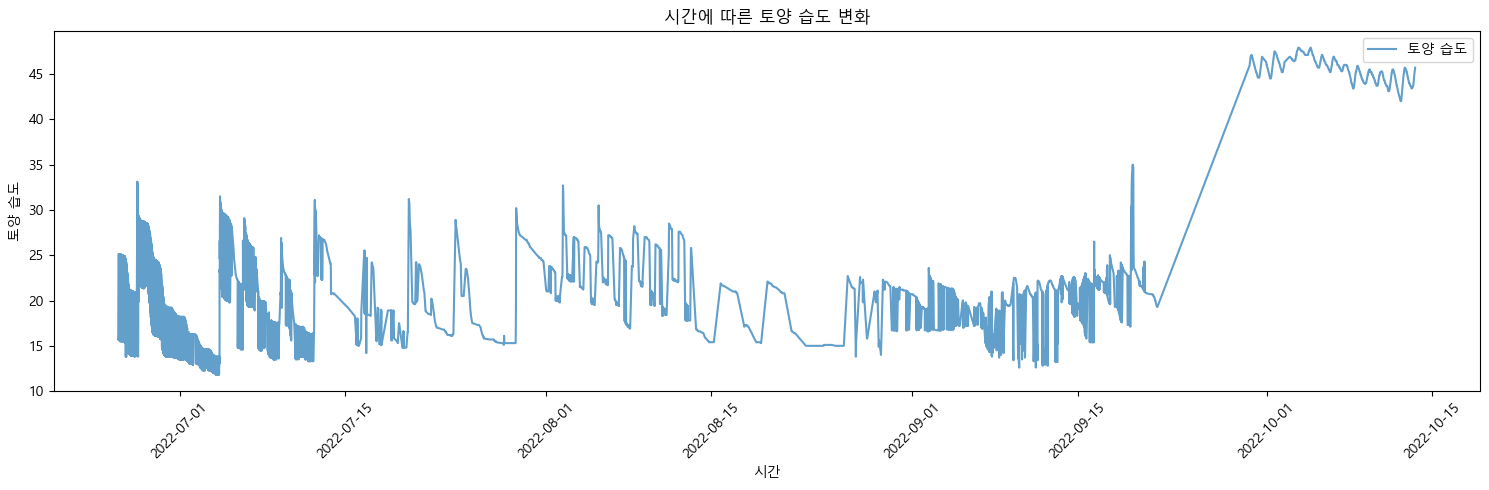

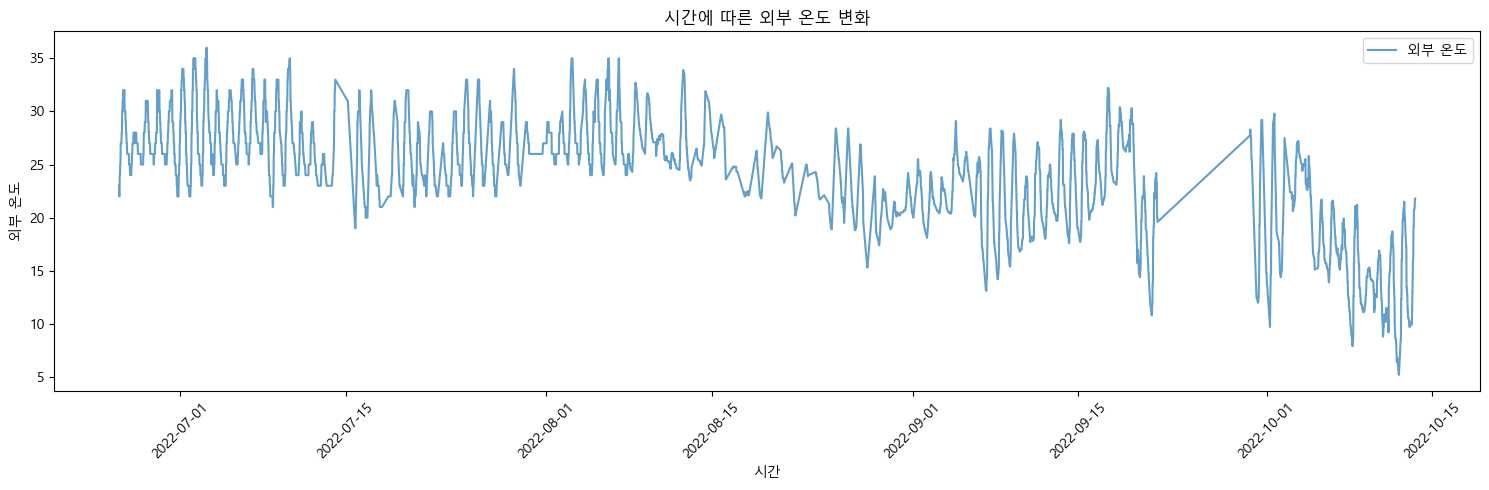

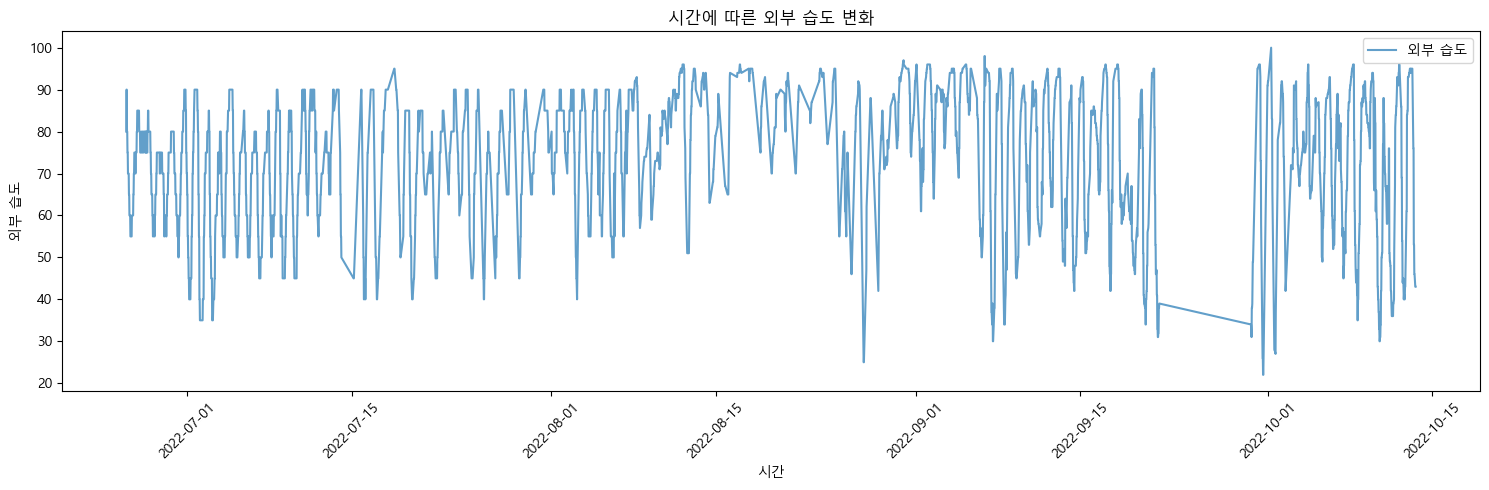

In [66]:

plt.figure(figsize=(15, 6))
for col in numerical_cols_lst:
    plt.figure(figsize=(15, 5))
    plt.plot(df['데이터 수신시간'], df[col], label=col, alpha=0.7)
    plt.title(f'시간에 따른 {col} 변화')
    plt.xlabel('시간')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

#### - 병해 유형(타깃)별 환경 특성

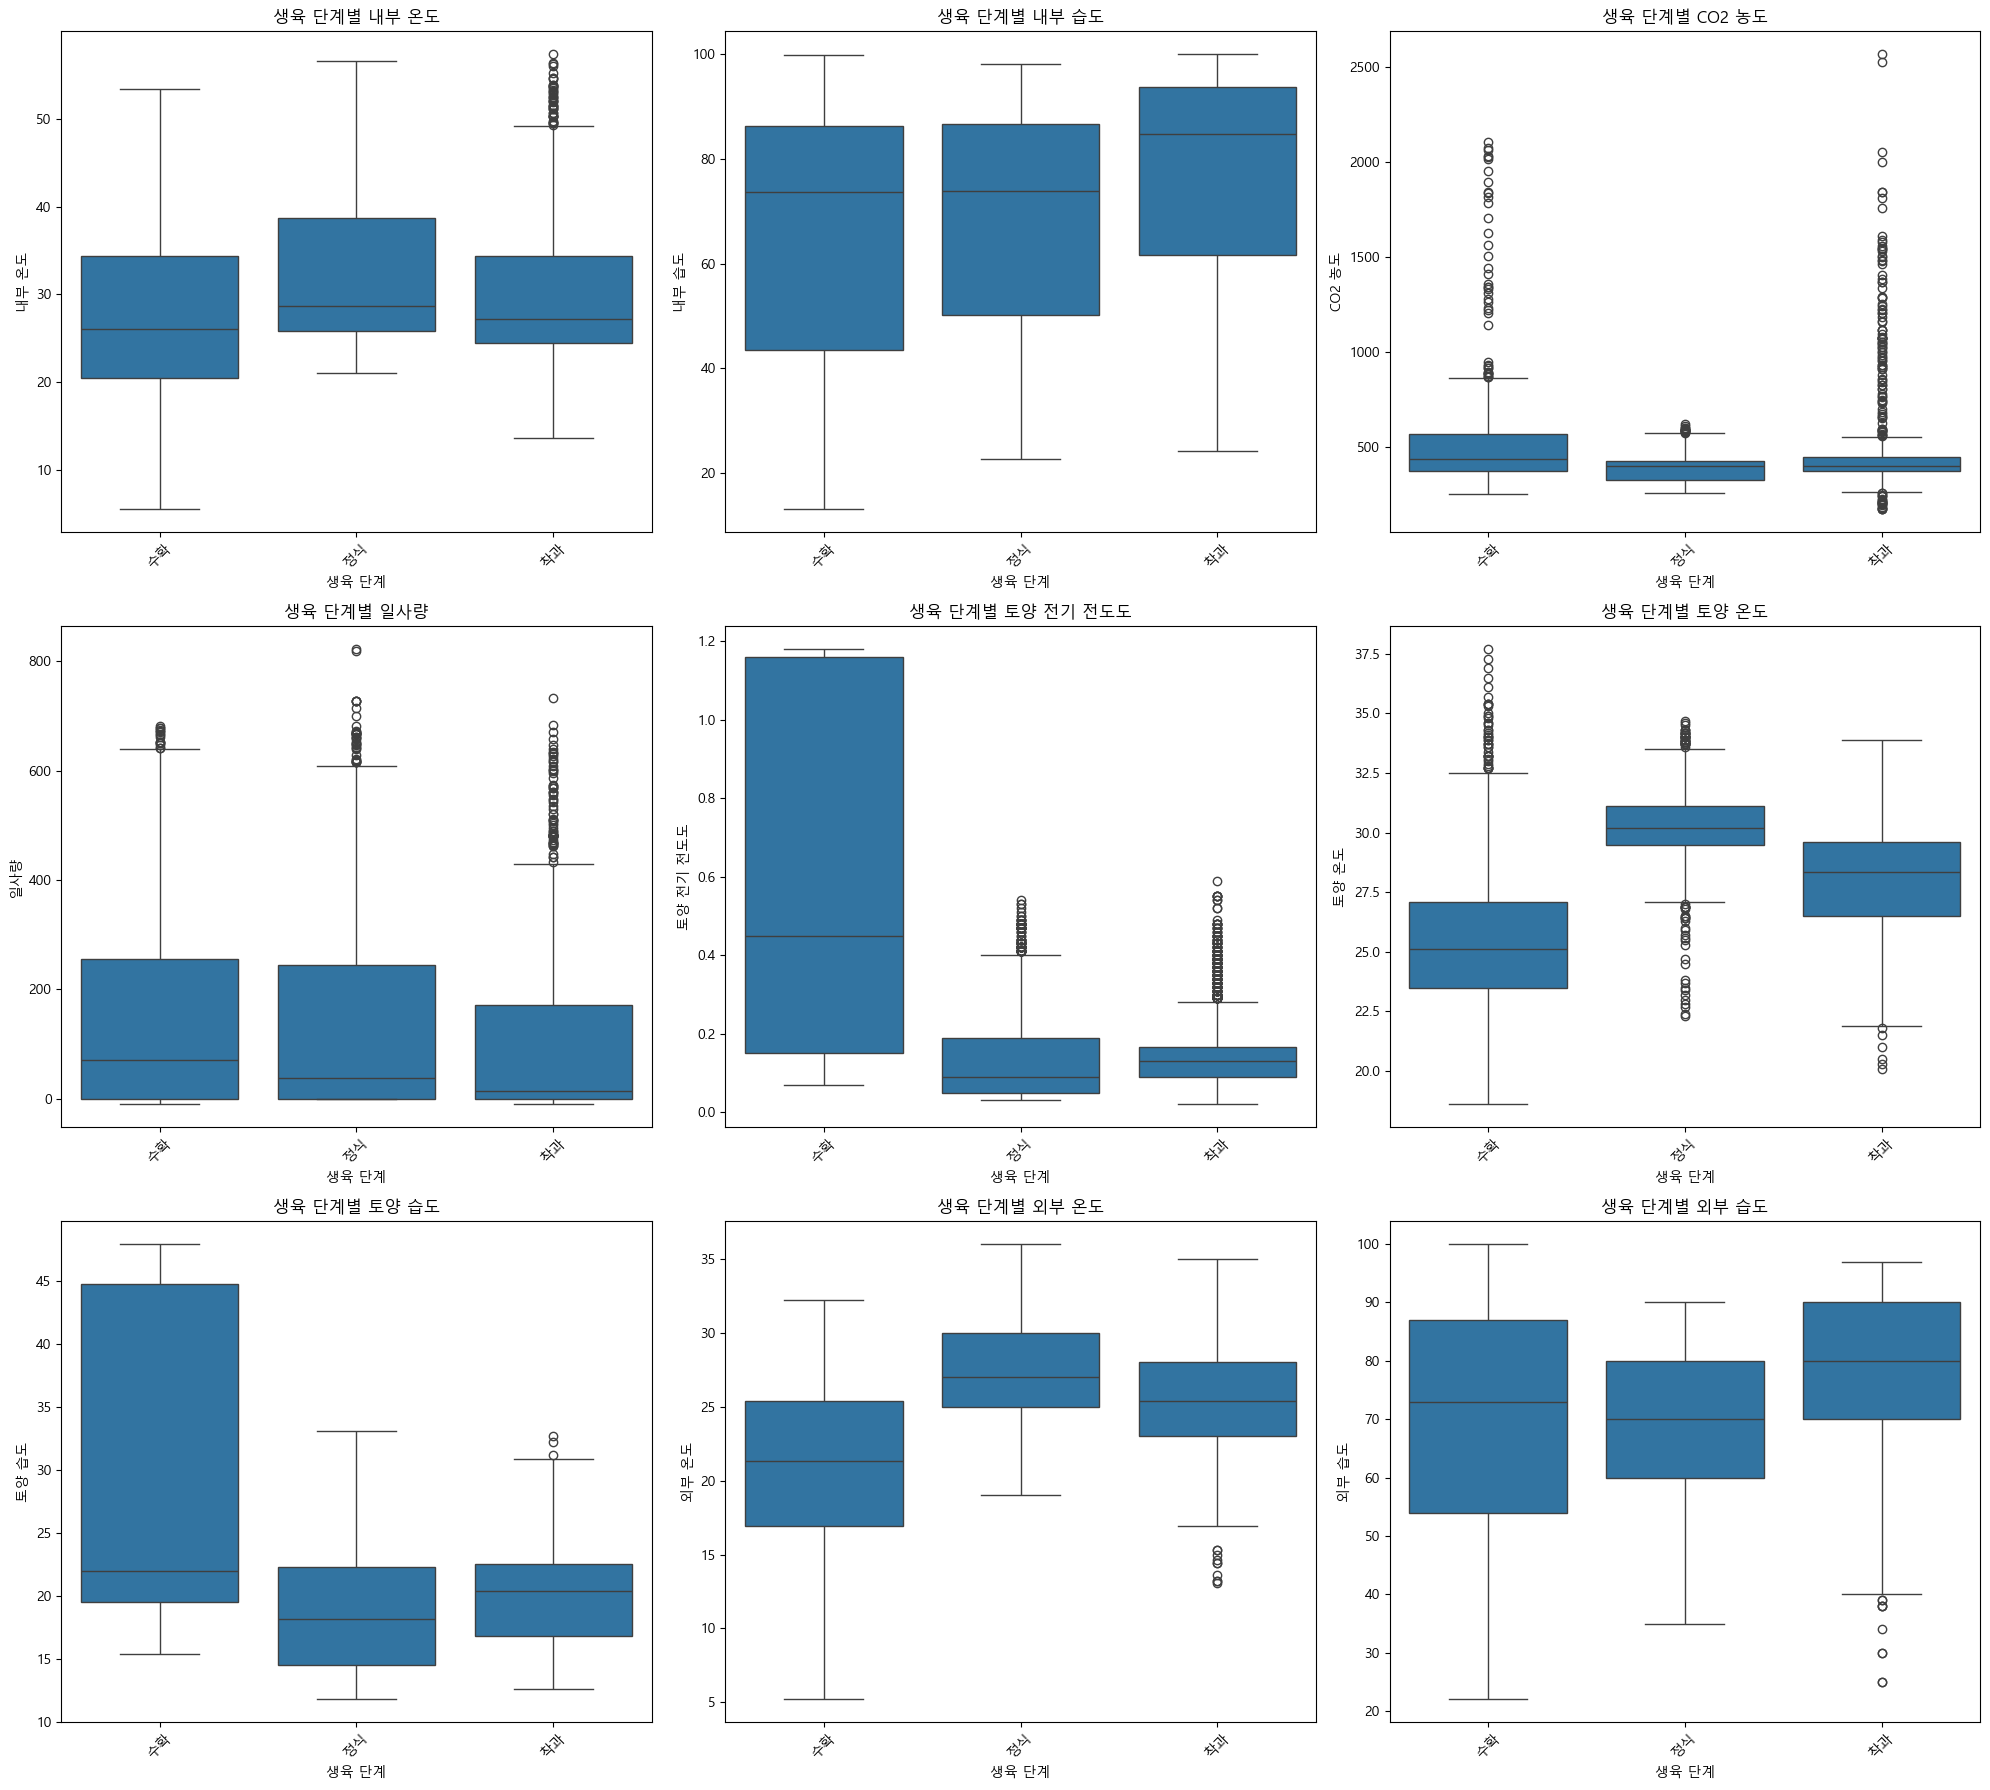

In [67]:
# 박스플롯 그리기

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(numerical_cols_lst):
    sns.boxplot(x=target_column, y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{target_column}별 {col}')
    axes[i].tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.show()

In [68]:
# 생육 단계별 평균과 표준편차 계산
grouped_stats = df.groupby(target_column)[numerical_cols].agg(['mean', 'std'])

display("병해유형별 환경 특성 통계", grouped_stats)

C:\Users\user\AppData\Local\Temp\ipykernel_3432\2836495641.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = df.groupby(target_column)[numerical_cols].agg(['mean', 'std'])


'병해유형별 환경 특성 통계'

내부 온도                내부 습도                 CO2 농도              \
            mean       std       mean        std        mean         std   
생육 단계                                                                      
수확     27.195329  9.818715  65.485035  23.739312  496.770761  231.457730   
정식     32.422992  8.442029  68.500442  20.872251  387.422992   70.424656   
착과     30.035630  8.494902  76.241092  20.898315  453.480672  237.999641   

              일사량             토양 전기 전도도                토양 온도            \
             mean         std      mean       std       mean       std   
생육 단계                                                                    
수확     139.223183  163.665789  0.606272  0.444222  25.587543  3.141023   
정식     139.974208  183.656218  0.146470  0.131606  30.270450  1.561149   
착과     106.380672  153.423008  0.166706  0.119242  28.053697  2.332528   

           토양 습도                 외부 온도                외부 습도             
            mean        std       mean       std       mean        std  
생육 단계                                                                   
수확     29.599308  12.407989  20.837889  5.638332  70.210208  18.707174  
정식     19.027782   5.016314  27.567428  3.110677  69.005158  13.413026  
착과     20.352185   4.002731  25.389496  3.706741  77.399160  14.566093